# [LAB-07] 4. 대응 표본 T-Test

## #01. 준비작업

### 1. 패키지 설치

대응표본 T-Test의 시각화를 위해 `statannotations` 패키지가 필요하다

In [1]:
!pip install --upgrade statannotations


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. 라이브러리 참조

In [2]:
from jussam import load_data
from helper import my_plot, my_stats
from pandas import melt, DataFrame

# 가설 검정 가정에 따른 검정 방법 선택을 위한 라이브러리
from scipy.stats import ttest_rel, wilcoxon

# 시각화에 필요한 라이브러리
from statannotations.Annotator import Annotator

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## #02. 예제 (1) - 사슴의 다리 길이 비교

### 1. 데이터 가져오기

- 사슴의 왼쪽 앞다리와 왼쪽 뒷다리의 길이를 측정한 자료를 통해 두 다리의 길이(cm)가 같은지 다른지 알고 싶다.
- 유의수준 0.05에서 검정하라.

In [3]:
df1 = load_data("deer")
df1.head()

📚 사슴의 왼쪽 앞다리와 왼쪽 뒷다리의 길이를 측정한 자료 (출처: 방송통신대학교 통계학개론)


,앞다리,뒷다리
사슴,,
1,138,142
2,136,140
3,147,144
4,139,144
5,143,142


### 2. 시각화를 위해 long 타입으로 데이터 재배치

In [4]:
df_melt = melt(df1, var_name='group', value_name='length')
df_melt

,group,length
0,앞다리,138
1,앞다리,136
2,앞다리,147
3,앞다리,139
4,앞다리,143
5,앞다리,141
6,앞다리,143
7,앞다리,145
8,앞다리,136
9,앞다리,146


### 3. 데이터 분포 시각화

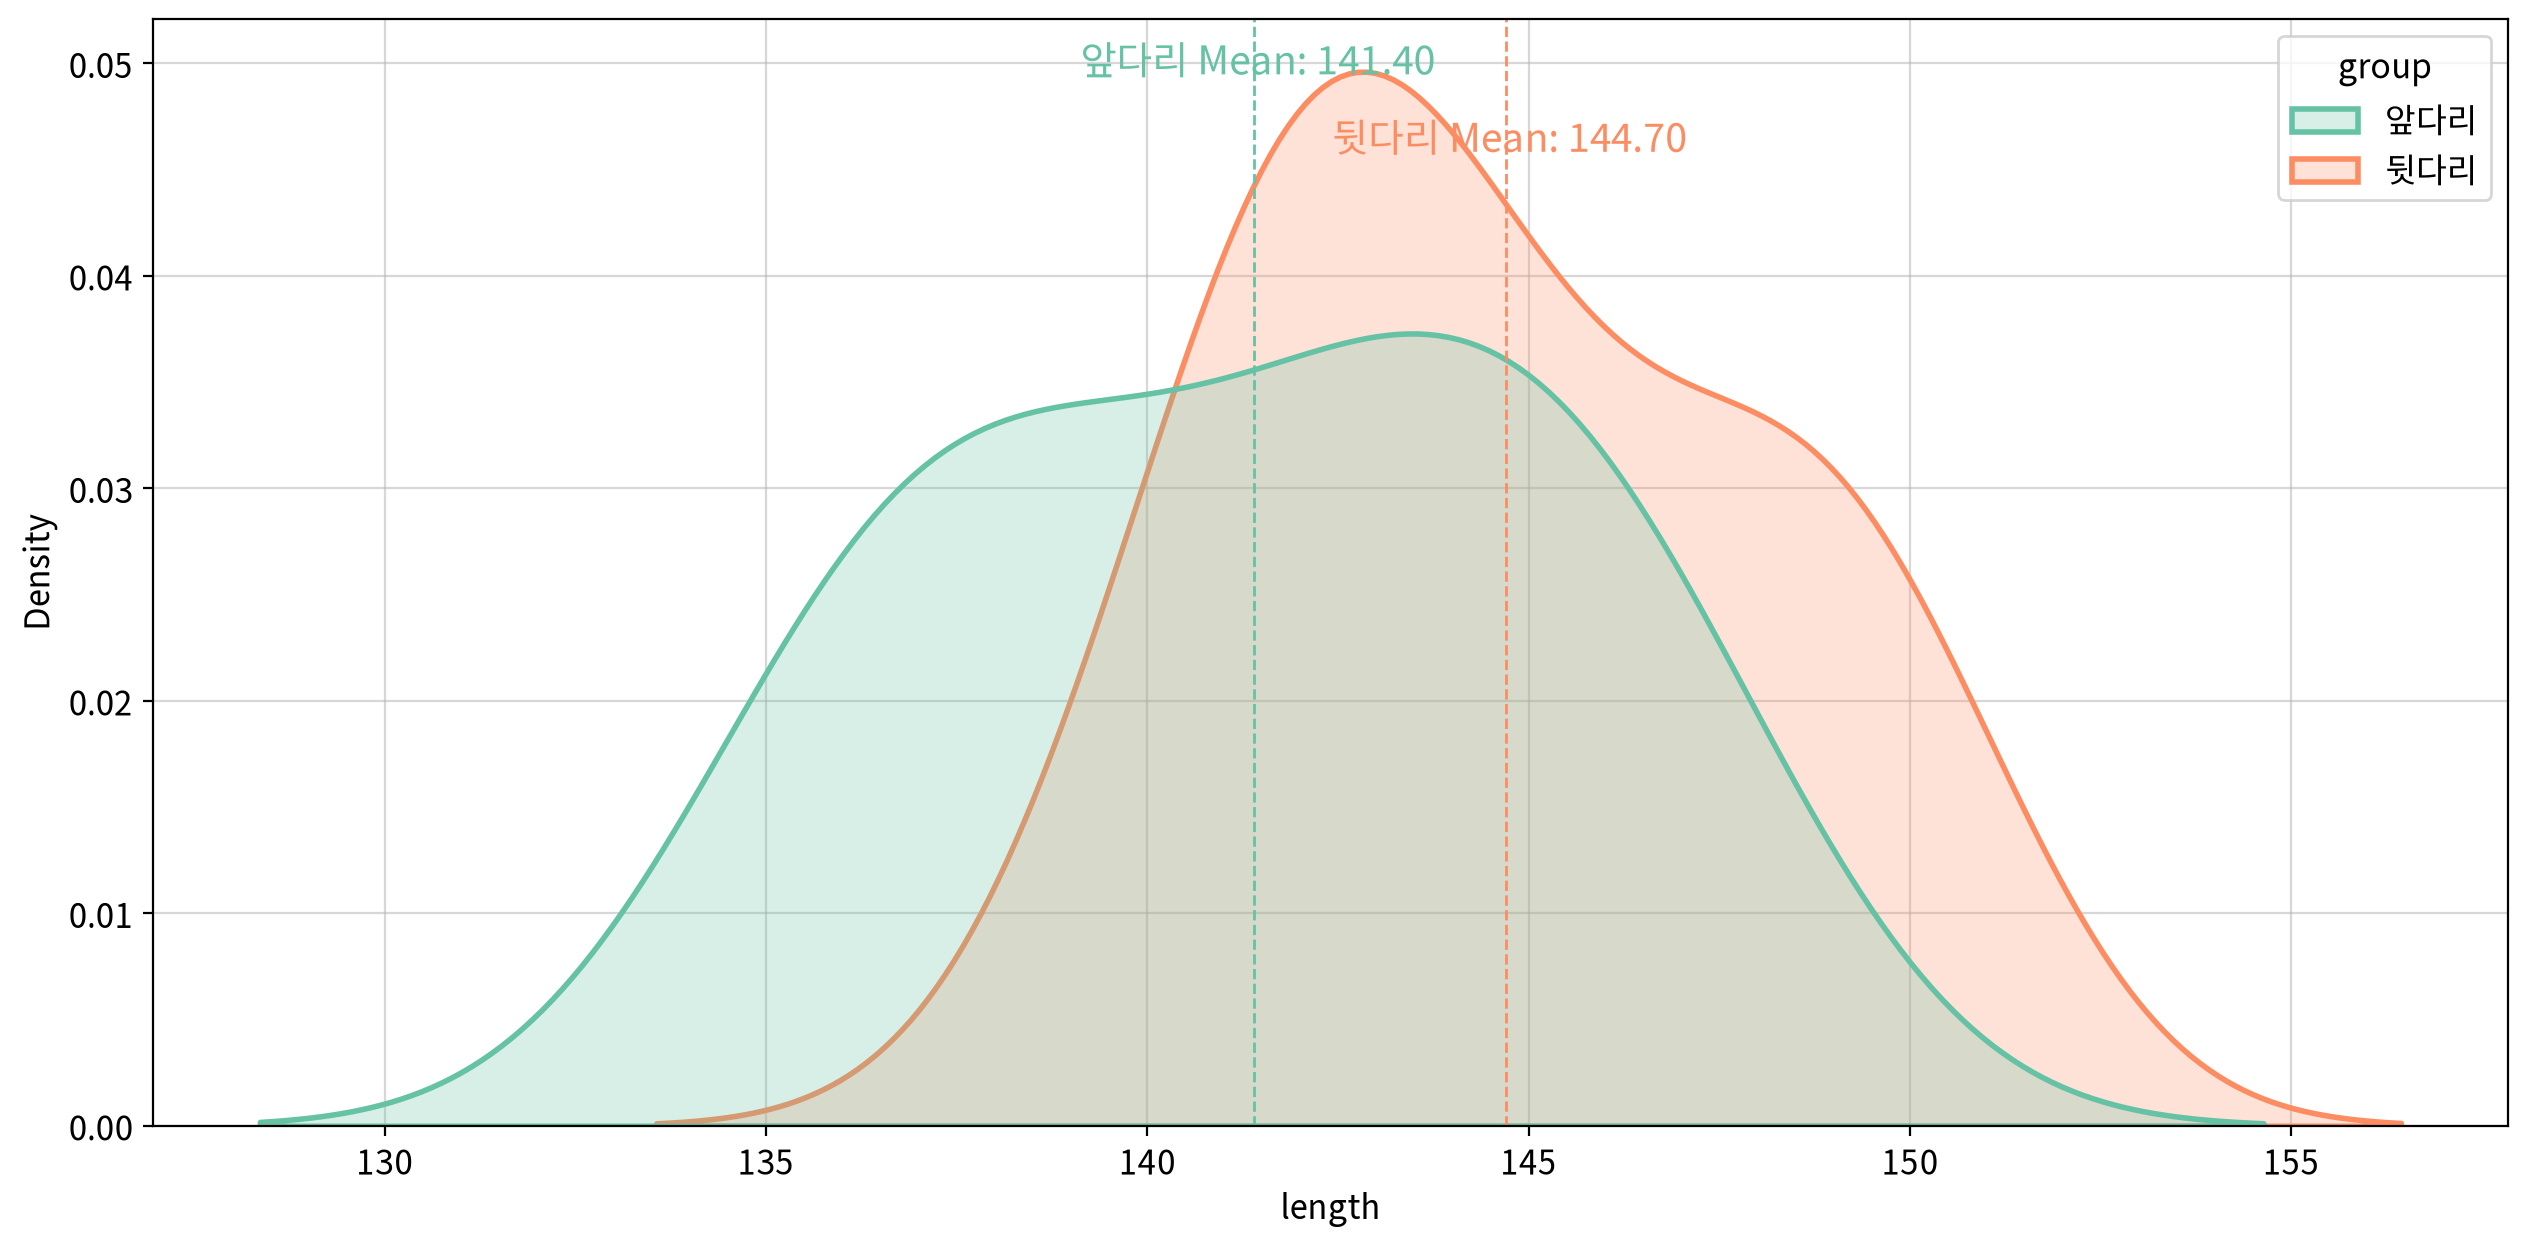

In [5]:
my_plot.kdeplot(data=df_melt, x='length', hue='group', fill=True, meanline=True, clevel=0.95, palette='Set2')

> 두 그룹의 커널 밀도 함수 그래프의 모양이 정규분포를 띄고 있는지 확실하지 않다.    
> 또한 두 그룹의 데이터 분포가 서로 다르기 때문에 등분산성을 충족하지 않지만 대응표본은 정규성만 충족하면 되므로 이는 영향이 없다.

### 4. 가설검정의 가정 확인을 위한 파생변수 생성

- 대응표본은 after에서 before를 뺀 값에 대하여 정규성을 검정해야 한다.

In [6]:
df_diff = df1.copy()
df_diff['diff'] = df_diff['뒷다리'] - df_diff['앞다리']
df_diff

,앞다리,뒷다리,diff
사슴,,,
1,138,142,4
2,136,140,4
3,147,144,-3
4,139,144,5
5,143,142,-1
6,141,146,5
7,143,149,6
8,145,150,5
9,136,142,6


### 5. 차이값에 대한 정규성 검정

In [7]:
my_stats.test_assumptions(df_diff, columns='diff')

,test,statistic,p-value,result
field,,,,
diff,normaltest,4.356,0.113,True


> 정규성을 충족하므로 **Paired T-Test**를 수행한다.

### 6. Paired T-Test - 양측검정

- 사슴의 앞다리와 뒷다리의 길이가 다른지 검정
  - 두 그룹간의 평균을 비교하기 위해서는 `alternative` 파라미터를 `two-sided`로 설정한다.
  - 기본값이므로 생략 가능함

| 구분 | 수식 | 내용 |
|---|---|---|
| 귀무가설($H_0$) | $\mu(앞다리) = \mu(뒷다리)$ | 사슴의 앞다리와 뒷다리 길이에는 차이가 없다 |
| 대립가설($H_1$) | $\mu(앞다리) \neq \mu(뒷다리)$ | 사슴의 앞다리와 뒷다리 길이에는 차이가 있다 |

In [8]:
s, p = ttest_rel(df1['앞다리'], df1['뒷다리'], alternative='two-sided')
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: -3.4138, p-value: 0.0077


> 차이값에 대한 양측 검정 결과 귀무가설을 기각하고 대립가설을 채택한다($p < 0.05$).    
> 즉, 사슴의 앞다리와 뒷다리의 길이는 통계적으로 유의한 차이가 있다.

### 7. Paired T-Test - 좌측 단측검정

| 구분 | 수식 | 내용 |
|---|---|---|
| 귀무가설($H_0$) | $\mu(B) \geq \mu(G)$ | 사슴의 앞다리는 뒷다리보다 짧지 않다 |
| 대립가설($H_1$) | $\mu(B) < \mu(G)$ | 사슴의 앞다리는 뒷다리보다 짧다 |

In [9]:
s, p = ttest_rel(df1['앞다리'], df1['뒷다리'], alternative='less')
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: -3.4138, p-value: 0.0039


> 차이값에 대한 t 통계량의 값이 `-3.4138`이고 이에 대응되는 유의확률이 `0.0039`이므로 귀무가설 기각하고 대립가설을 채택한다($p < 0.05$).    
> 즉, 앞다리는 뒷다리보다 통계적으로 유의하게 짧다.

### 8. Paired T-Test - 우측 단측검정

| 구분 | 수식 | 내용 |
|---|---|---|
| 귀무가설($H_0$) | $\mu(B) \leq \mu(G)$ | 사슴의 앞다리는 뒷다리보다 길지 않다 |
| 대립가설($H_1$) | $\mu(B) > \mu(G)$ | 사슴의 앞다리는 뒷다리보다 길다 |

In [10]:
s, p = ttest_rel(df1['앞다리'], df1['뒷다리'], alternative='greater')
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: -3.4138, p-value: 0.9961


> 차이값에 대한 t 통계량의 값이 `-3.414`이고 이에 대응되는 유의확률이 `0.9961`이므로 귀무가설을 기각할 수 없다($p \geq 0.05$).    
> 즉, 사슴의 앞다리는 사슴의 뒷다리보다 통계적으로 유의하게 길지 않다.

### 7. 가설검정 시각화

- 상자그림에 Annotator 클래스의 객체를 사용하여 평균 비교를 추가할 수 있다.
  - 양측검정만 지원하고 단측검정은 지원하지 않음

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

앞다리 vs. 뒷다리: t-test paired samples, P_val:7.703e-03 t=-3.414e+00


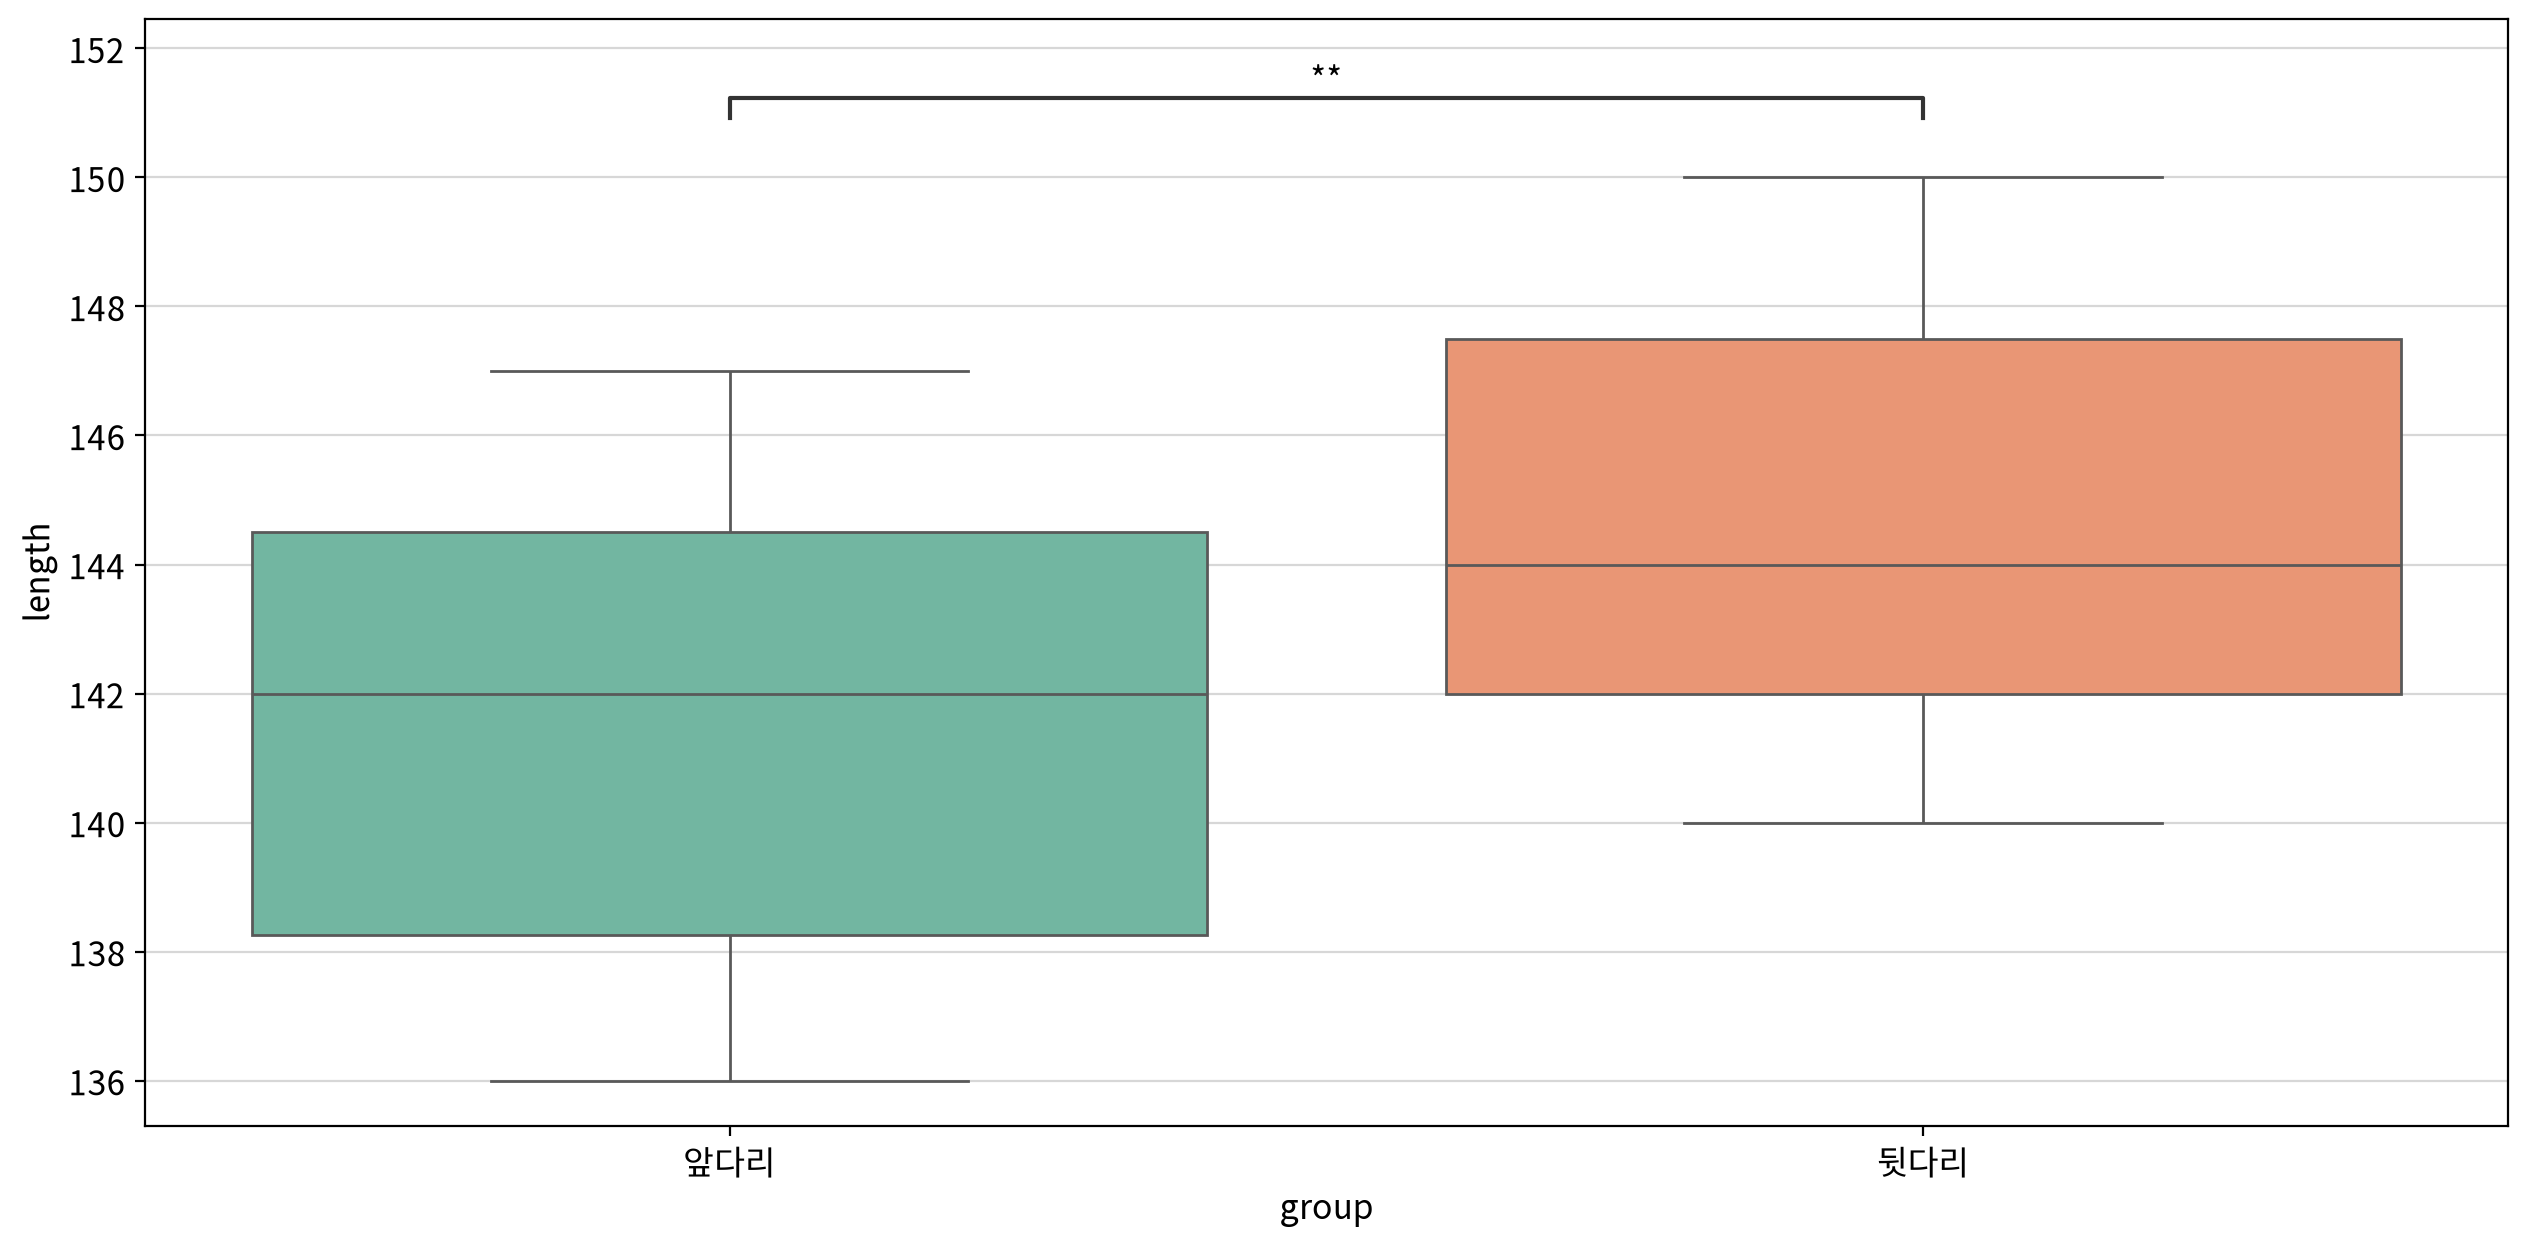

In [11]:
fig, ax = my_plot.init()
my_plot.boxplot(df_melt, x='group', y='length', hue='group', palette='Set2', ax=ax)

# 독립표본 T검정 결과를 시각화에 추가
annotator = Annotator(data=df_melt,
                      x='group',
                      y='length',
                      pairs=[('앞다리', '뒷다리')],
                      ax=ax)
                       
# 가설검정 알고리즘 종류 (`t-test_ind`, `t-test_paired`, `t-test_welch`, `Mann-Whitney`, `Mann-Whitney-gt`, `Mann-Whitney-ls`, `Levene`, `Wilcoxon`, `Kruskal` 등을 지원)
annotator.configure(test= 't-test_paired')
annotator.apply_and_annotate()

my_plot.show()

## #03. 예제 (2) - 자동차 첨가제가 주행거리에 미치는 영향

### 1. 데이터 가져오기

- 다섯 종류의 새 차에 대하여 같은 종류의 차 두 대 중에서 한 대를 랜덤하게 선택하여 첨가제를 사용하고, 다른 한 대에는 첨가제를 사용하지 않고 같은 운전자가 같은 장소에서 운전한 결과 다음과 같은 자료를 얻었다.
  - 첨가제를 사용하면 주행거리가 늘어난다고 할 수 있는지 유의수준 5%에서 검정하여 보라.
  - 그룹A : 첨가제를 사용한 경우, 그룹B : 첨가제를 사용하지 않은 경우

> 같은 종류의 차 2대가 한 쌍으로 묶여 있고 한 대는 첨가제 사용, 다른 한 대는 미사용이므로 대응표본 비교임

In [12]:
df2 = load_data("oil")
df2

📚 다섯 종류의 새 차에 대하여 같은 종류의 차 두 대 중에서 한 대를 랜덤하게 선택하여 첨가제를 사용하고, 다른 한 대에는 첨가제를 사용하지 않고 같은 운전자가 같은 장소에서 운전한 후 주행거리를 측정한 결과 데이터 (출처: 방송통신대학교 통계학개론)


,그룹A,그룹B
0,13.200,11.700
1,13.100,17.984
2,16.300,12.290
3,14.900,9.862
4,14.200,8.871
5,16.100,37.034
6,15.100,25.111
7,13.600,12.728
8,15.800,11.346
9,14.200,8.400


### 2. 시각화를 위한 데이터 재배치

- melt 함수를 사용하여 wide 형 데이터를 long 형으로 변환한다.

In [13]:
df2_melt = melt(df2, var_name="group", value_name="length")
df2_melt.head()

,group,length
0,그룹A,13.200
1,그룹A,13.100
2,그룹A,16.300
3,그룹A,14.900
4,그룹A,14.200


### 3. 데이터 분포 시각화

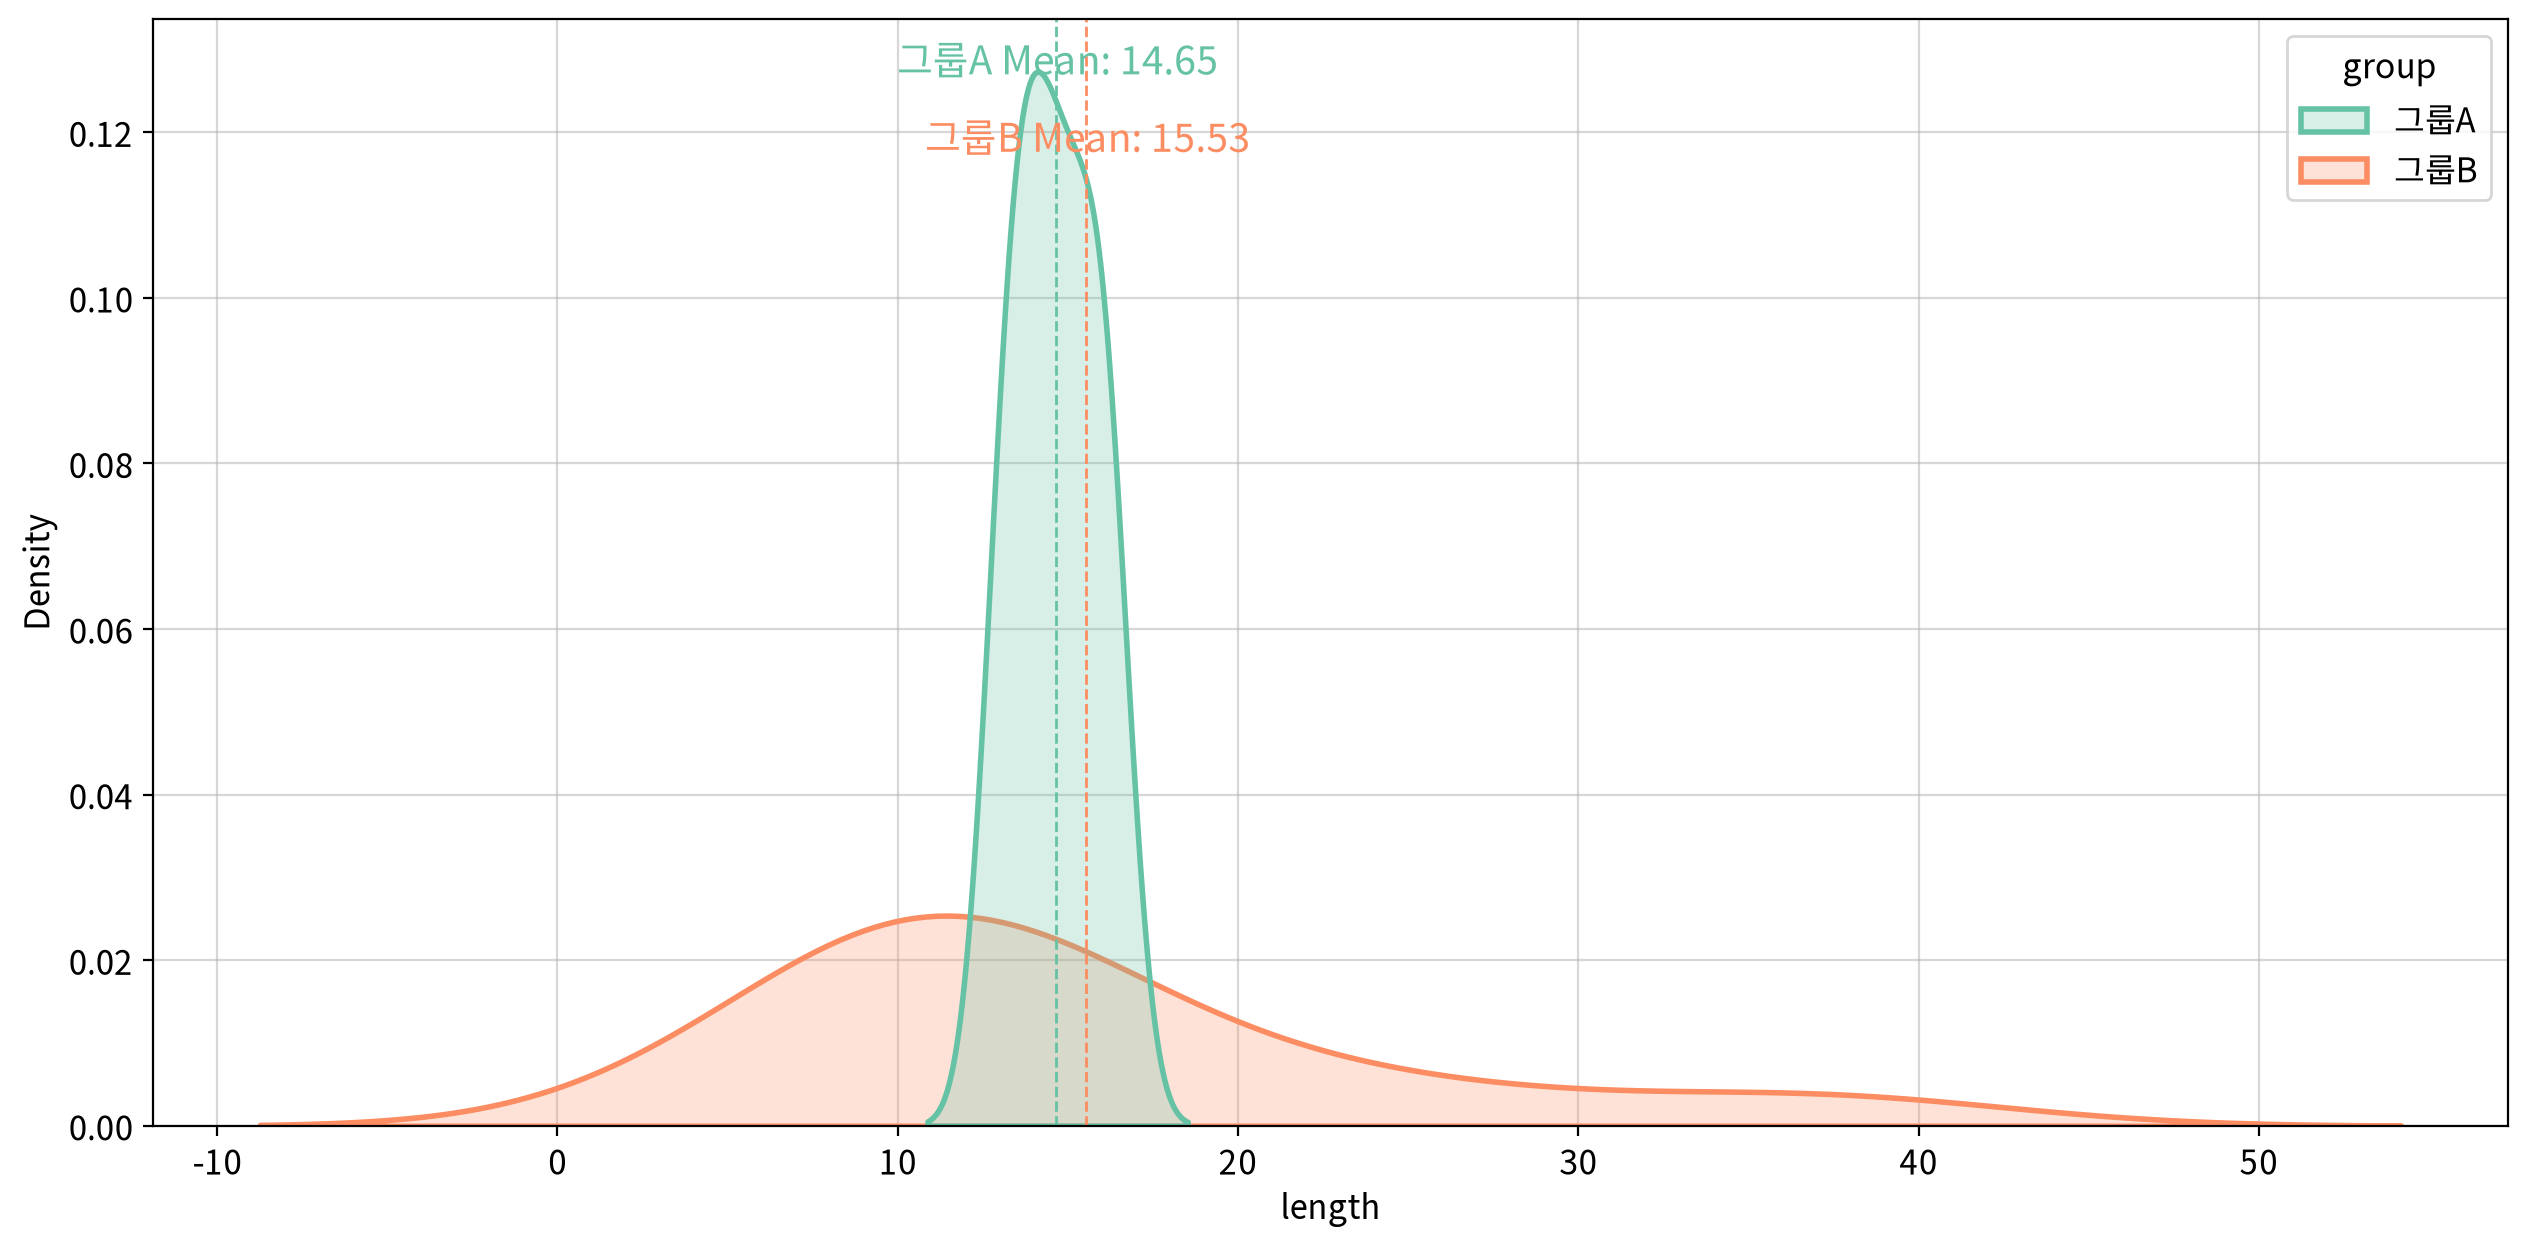

In [14]:
my_plot.kdeplot(data=df2_melt, x='length', hue='group', fill=True, meanline=True, clevel=0.95, palette='Set2')

> 그룹 A는 정규분포 모양을 띄지만 그룹 B는 약한 우측 꼬리 형태를 띄고 있어 정규성 가정을 충족하지 않는다.    
> 또한 두 그룹의 분산(데이터의 퍼짐 정도)가 극명하게 다르다.

### 4. 가설검정 가정 확인

In [15]:
# 차이값 계산
df2_diff = df2.copy()
df2_diff['diff'] = df2_diff['그룹A'] - df2_diff['그룹B']

# 차이에 대한 정규성 검정
my_stats.test_assumptions(data=df2_diff, columns='diff')

,test,statistic,p-value,result
field,,,,
diff,normaltest,7.990,0.018,False


> 데이터가 정규성을 만족하지 않는다. (대응표본 T 검정은 등분산성을 확인하지 않는다.)    
> 정규성을 충족하지 않기 때문에 **Wilcoxon signed-rank test**를 수행해야 한다.

### 5. Wilcoxon signed-rank test - 양측검정

| 구분 | 수식 | 내용 |
|---|---|---|
| 귀무가설($H_0$) | $\mu(A) = \mu(B)$ | 그룹A와 그룹B의 주행거리에는 차이가 없다.<br/>즉, 실험에 사용된 첨가제는 주행거리에 영향을 주지 않는다. |
| 대립가설($H_1$) | $\mu(A) \neq \mu(B)$ | 그룹A와 그룹B의 주행거리에는 차이가 있다.<br/>즉, 실험에 사용된 첨가제는 주행거리에 영향을 준다. |

In [16]:
s, p = wilcoxon(df2['그룹A'], df2['그룹B'], alternative='two-sided')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 24.0000, p-value: 0.7695


> 첨가제를 사용한 그룹과 첨가제를 사용하지 않은 그룹의 평균 주행거리에 대해 양측검정을 수행한 결과 통계적으로 유의미한 차이를 보이지 않았다($p \geq 0.5$).

### 6. Wilcoxon signed-rank test - 좌측 단측검정

| 구분 | 수식 | 내용 |
|---|---|---|
| 귀무가설($H_0$) | $\mu(A) \geq \mu(B)$ | 첨가제를 사용한 그룹 A의 주행거리는<br/>첨가제를 사용하지 않은 그룹 B의 주행거리보다 작지 않다.<br/>즉, 실험에 사용된 첨가제는 주행거리에 나쁜 영향을 주지는 않는다.|
| 대립가설($H_1$) | $\mu(A) \lt \mu(B)$ | 첨가제를 사용한 그룹 A의 주행거리는<br/>첨가제를 사용하지 않은 그룹 B의 주행거리보다 작다.<br/>즉, 실험에 사용된 첨가제는 **주행거리에 안좋은 영향**을 준다. (부정적 영향) |

In [17]:
s, p = wilcoxon(df2['그룹A'], df2['그룹B'], alternative='less')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 31.0000, p-value: 0.6523


> 첨가제를 사용한 A그룹과 첨가제를 사용하지 않은 B그룹의 평균 주행거리에 대해 좌측 단측검정을 수행한 결과 통계적으로 유의미한 차이를 보이지 않았다($p \geq 0.5$)    
> --> 주행거리를 늘리거나 주행거리에 영향이 없다는 의미이다.    
> --> 좌측 단측 검정에서 귀무가설이 채택된 경우 부정적인 영향이 없다는 것만 증명될 뿐, 긍정적 영향을 주는지는 알 수 없다.

### 7. Wilcoxon signed-rank test - 우측 단측검정

| 구분 | 수식 | 내용 |
|---|---|---|
| 귀무가설($H_0$) | $\mu(A) \leq \mu(B)$ | 첨가제를 사용한 그룹 A의 주행거리는<br/>첨가제를 사용하지 않은 그룹 B의 주행거리보다 크지 않다.<br/>즉, 실험에 사용된 첨가제는 주행거리에 긍정적 영향을 주지는 않는다.|
| 대립가설($H_1$) | $\mu(A) \gt \mu(B)$ | 첨가제를 사용한 그룹 A의 주행거리는<br/>첨가제를 사용하지 않은 그룹 B의 주행거리보다 크다.<br/>즉, 실험에 사용된 첨가제는 **주행거리에 좋은 영향**을 준다. (긍정적 영향) |

In [18]:
s, p = wilcoxon(df2['그룹A'], df2['그룹B'], alternative='greater')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 31.0000, p-value: 0.3848


> 첨가제를 사용한 A그룹과 첨가제를 사용하지 않은 B그룹의 평균 주행거리에 대해 좌측 단측검정을 수행한 결과 통계적으로 유의미한 차이를 보이지 않았다($p \geq 0.5$)    
> --> 주행거리를 늘리거나 주행거리에 영향이 없다는 의미이다.    
> --> 좌측 단측 검정에서 귀무가설이 채택된 경우 부정적인 영향이 없다는 것만 증명될 뿐, 긍정적 영향을 주는지는 알 수 없다.

### 8. 가설검정 시각화

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹A vs. 그룹B: Wilcoxon test (paired samples), P_val:7.695e-01 Stat=2.400e+01


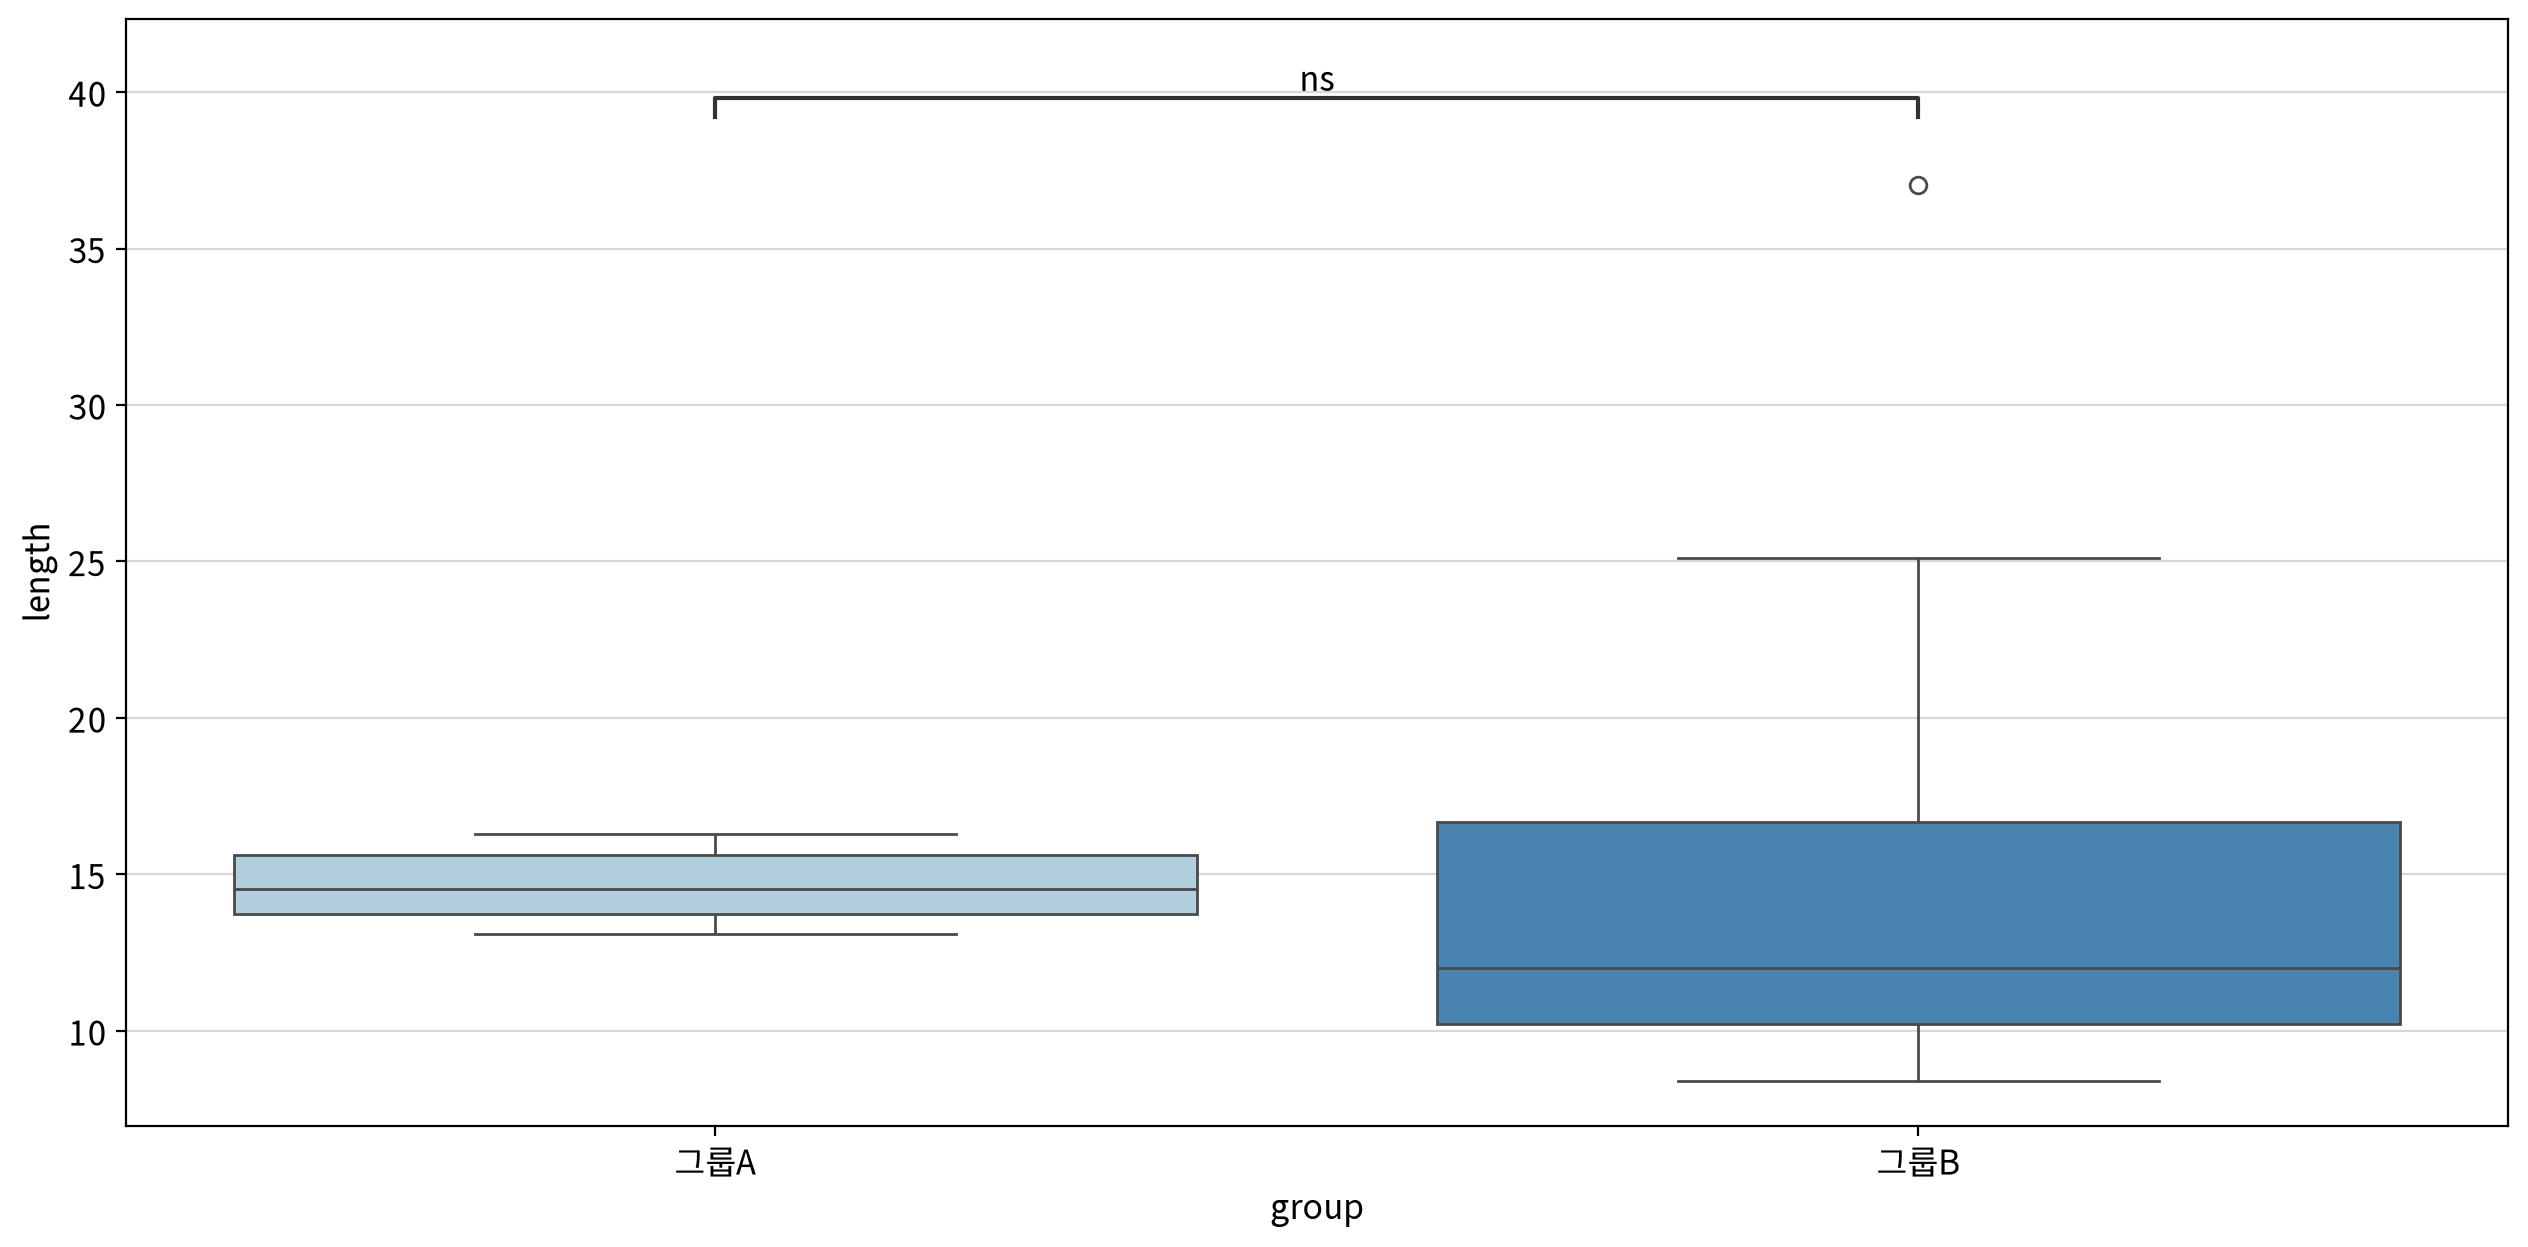

In [19]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df2_melt, x="group", y="length", hue="group", palette="Blues", ax=ax)

# 독립표본 T검정 결과를 시각화에 추가
annotator = Annotator(data=df2_melt,                # 데이터프레임
                       x='group',                   # x축 변수
                       y='length',                  # y축 변수
                       pairs=[('그룹A', '그룹B')],   # 비교할 그룹 쌍
                       ax=ax)                       # 그래프 축
                       
# 가설검정 알고리즘 종류 (`t-test_ind`, `t-test_paired`, `t-test_welch`, `Mann-Whitney`, `Mann-Whitney-gt`, `Mann-Whitney-ls`, `Levene`, `Wilcoxon`, `Kruskal` 등을 지원)
annotator.configure(test='Wilcoxon')
annotator.apply_and_annotate()

my_plot.show()

## #04. 모듈화 기능 확인

### 1. 사슴 다리 길이 비교

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

앞다리 vs. 뒷다리: t-test paired samples, P_val:7.703e-03 t=-3.414e+00


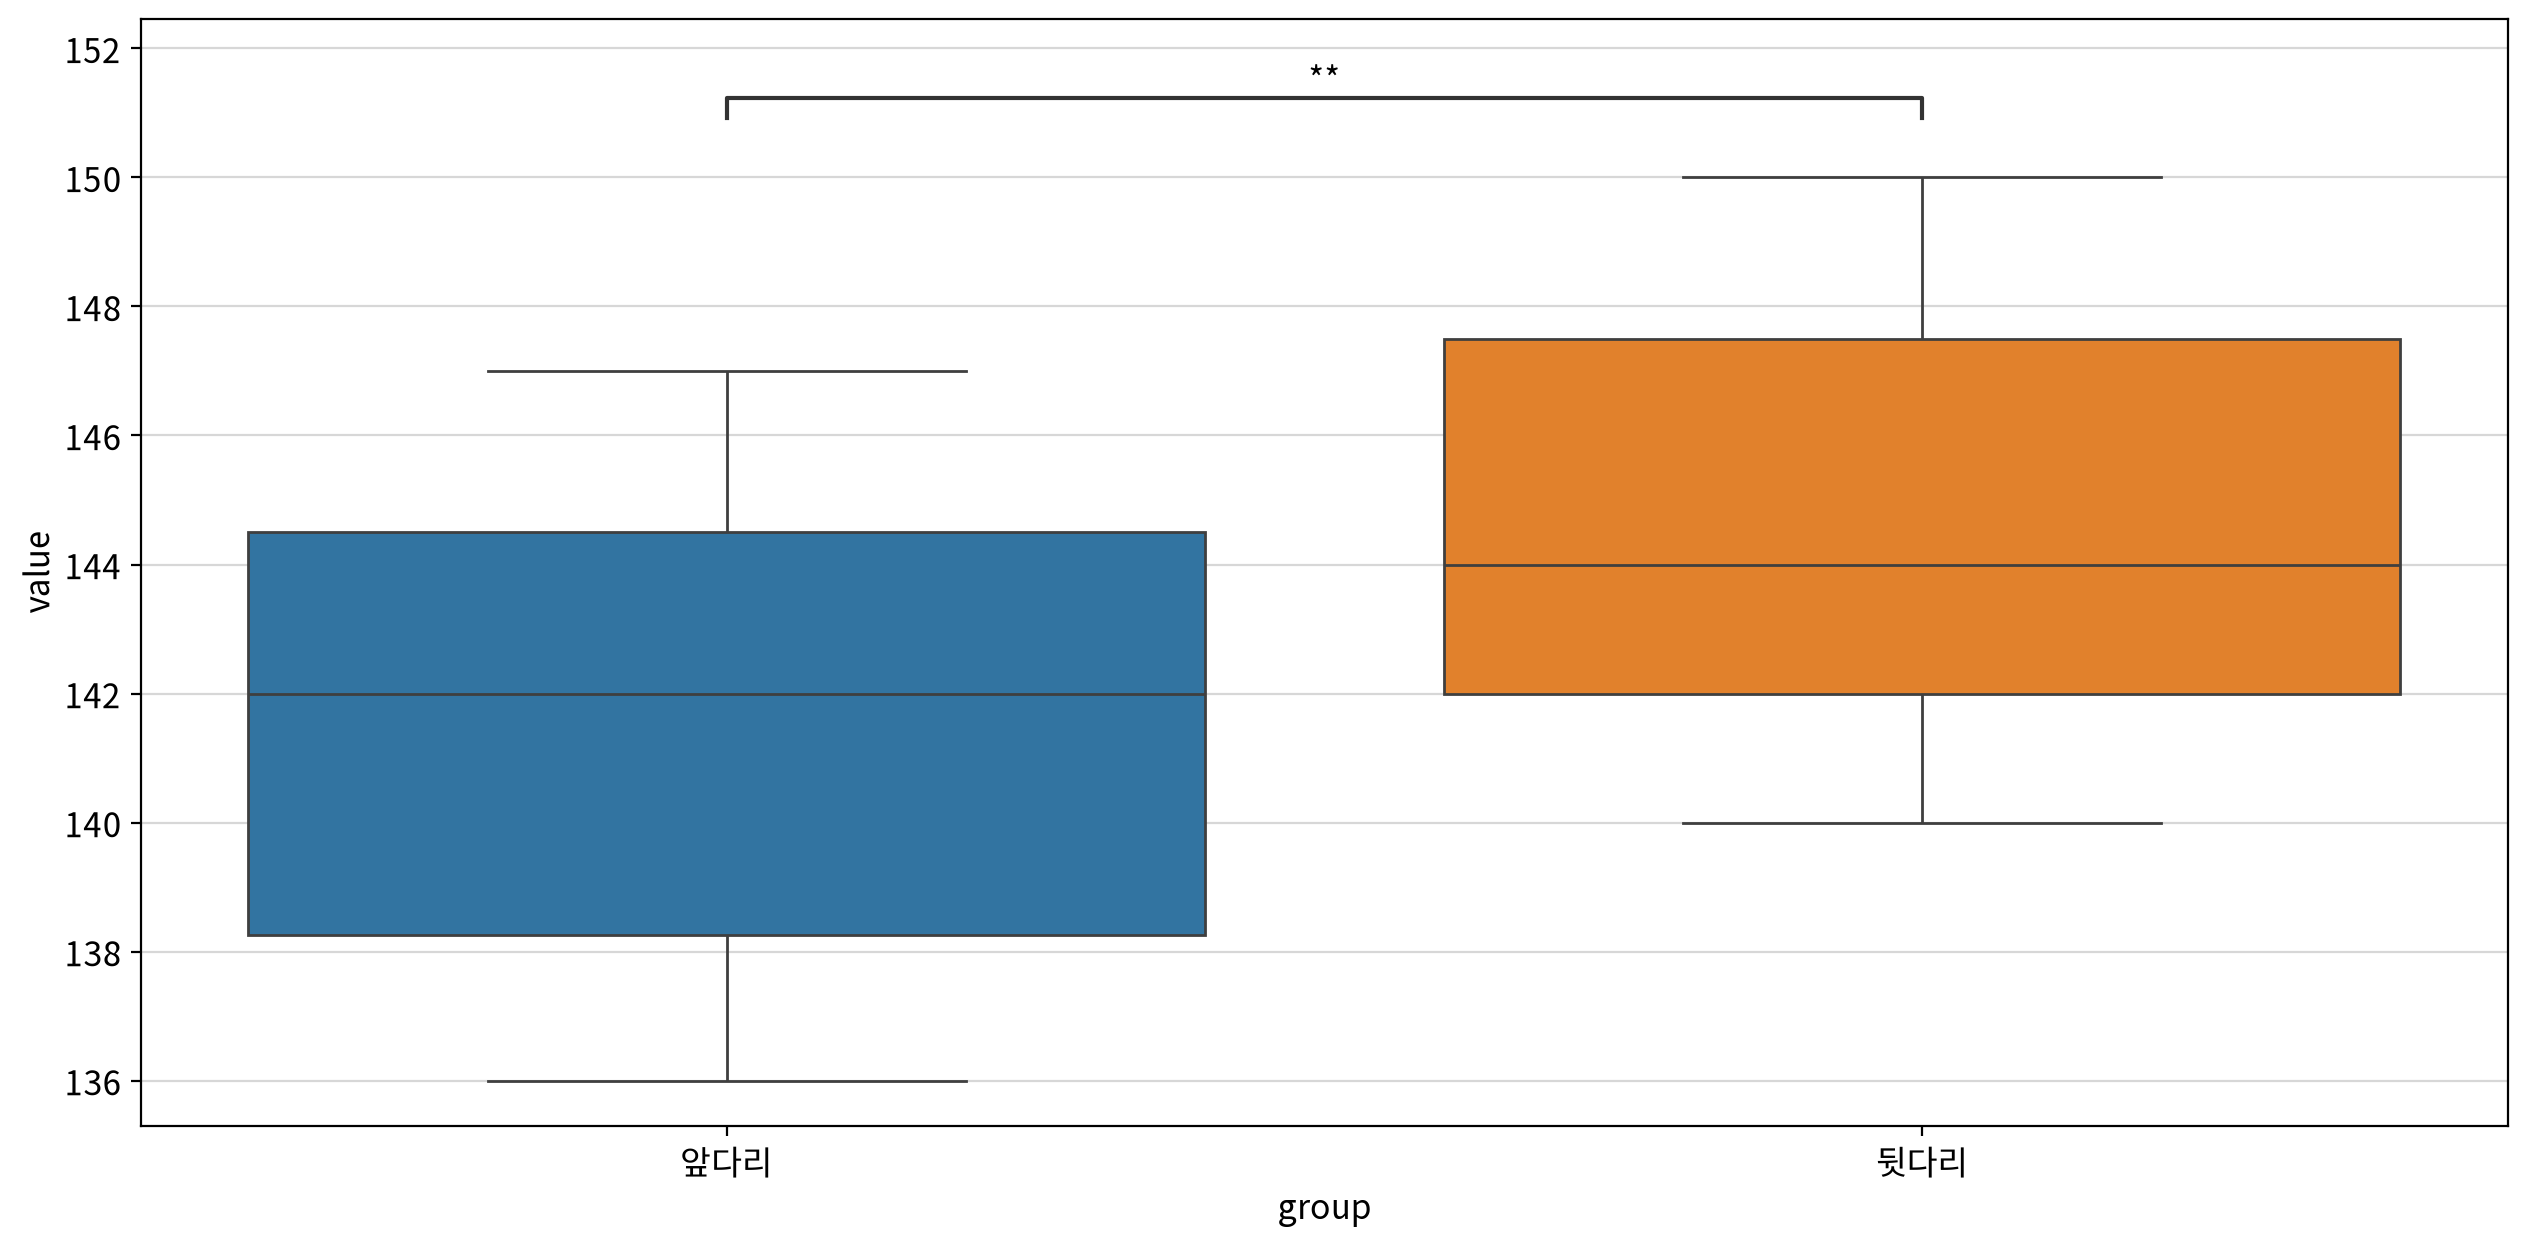

statistic  p-value  significant     result
test          alternative                                            
Paired t-test two-sided        3.414    0.008         True  뒷다리 ≠ 앞다리
              less             3.414    0.996        False  뒷다리 ≥ 앞다리
              greater          3.414    0.004         True  뒷다리 > 앞다리

In [20]:
my_stats.test_paired(data=df1, before='앞다리', after='뒷다리')

### 2. 자동차 첨가제가 주행거리에 미치는 영향

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹A vs. 그룹B: Wilcoxon test (paired samples), P_val:7.695e-01 Stat=2.400e+01


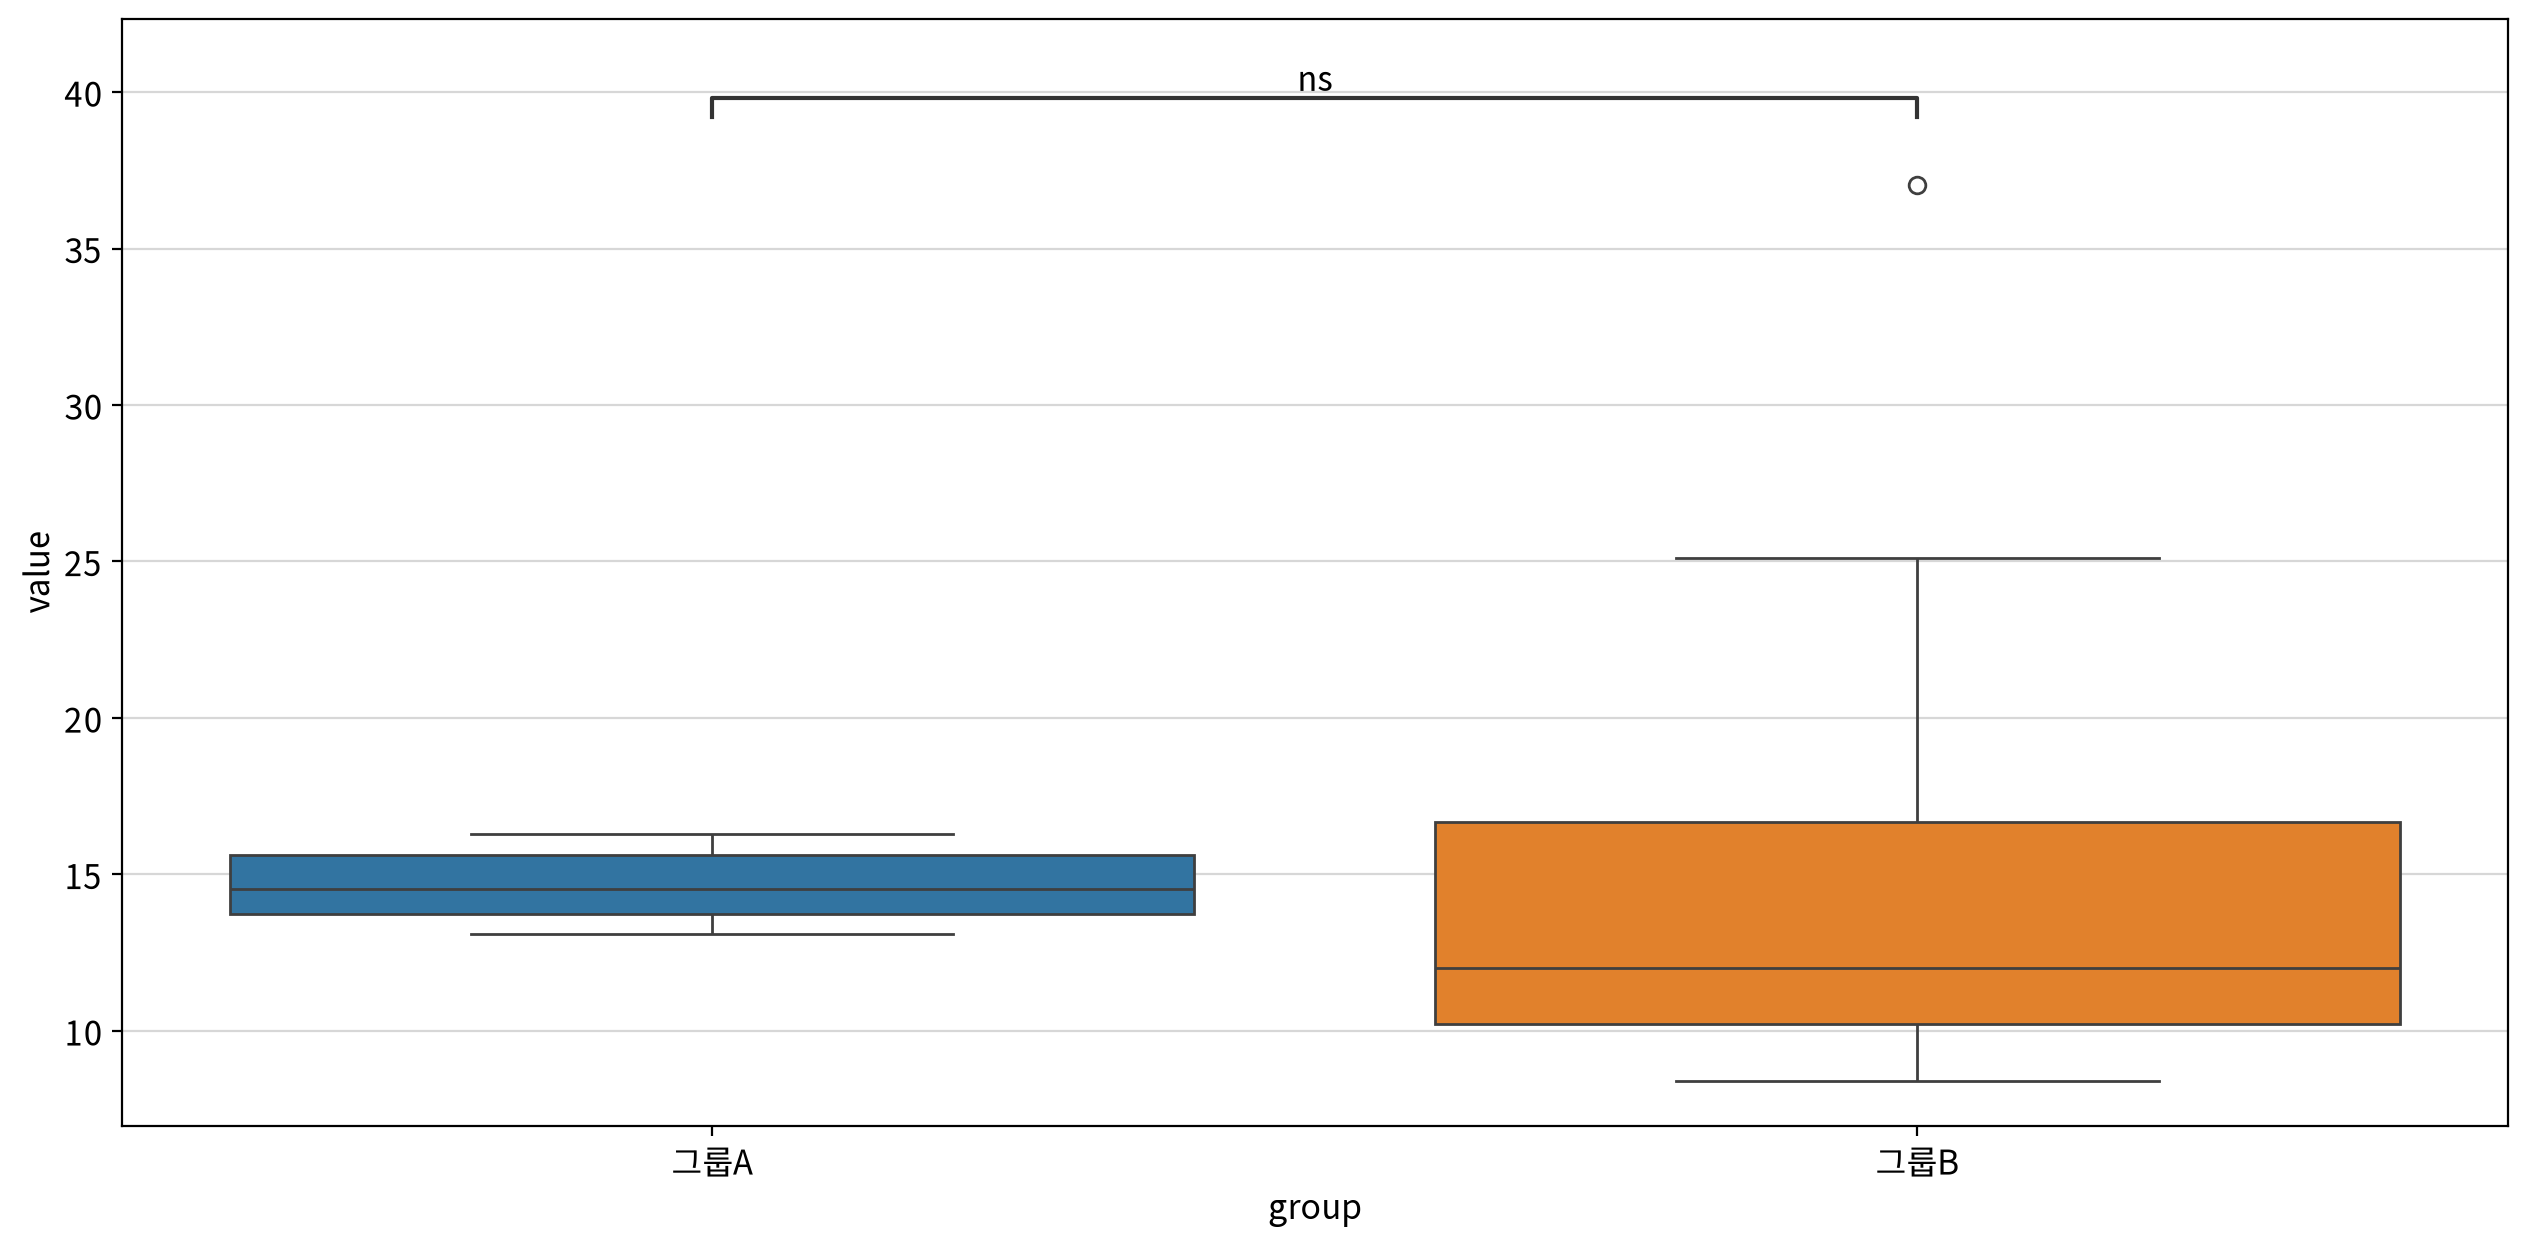

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided       24.000    0.769        False   
                          less            24.000    0.385        False   
                          greater         24.000    0.652        False   

                                          result  
test                      alternative             
Wilcoxon signed-rank test two-sided    그룹B = 그룹A  
                          less         그룹B ≥ 그룹A  
                          greater      그룹B ≤ 그룹A

In [21]:
my_stats.test_paired(data=df2, before='그룹A', after='그룹B')

### 문제 1.
#### bllod_pressure 데이터셋은 부인 15명을 대상으로 평상시 혈압을 측정한 뒤, 이들에게 이 피임약을 일정 기간 복용하게 한 후 이들의 혈압을 다시 측정한 결과를 기록한 데이터이다. 이 데이터를 통해 피임약 복용이 혈압에 영향을 주는지 분석하라.

📚 부인 15명을 대상으로 평상시 혈압을 측정한 뒤, 이들에게 이 피임약을 일정 기간 복용하게 한 후 이들의 혈압을 다시 측정한 결과를 기록한 데이터 (출처: 방송통신대학교 통계학개론)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

복용전 vs. 복용후: t-test paired samples, P_val:7.749e-03 t=3.105e+00


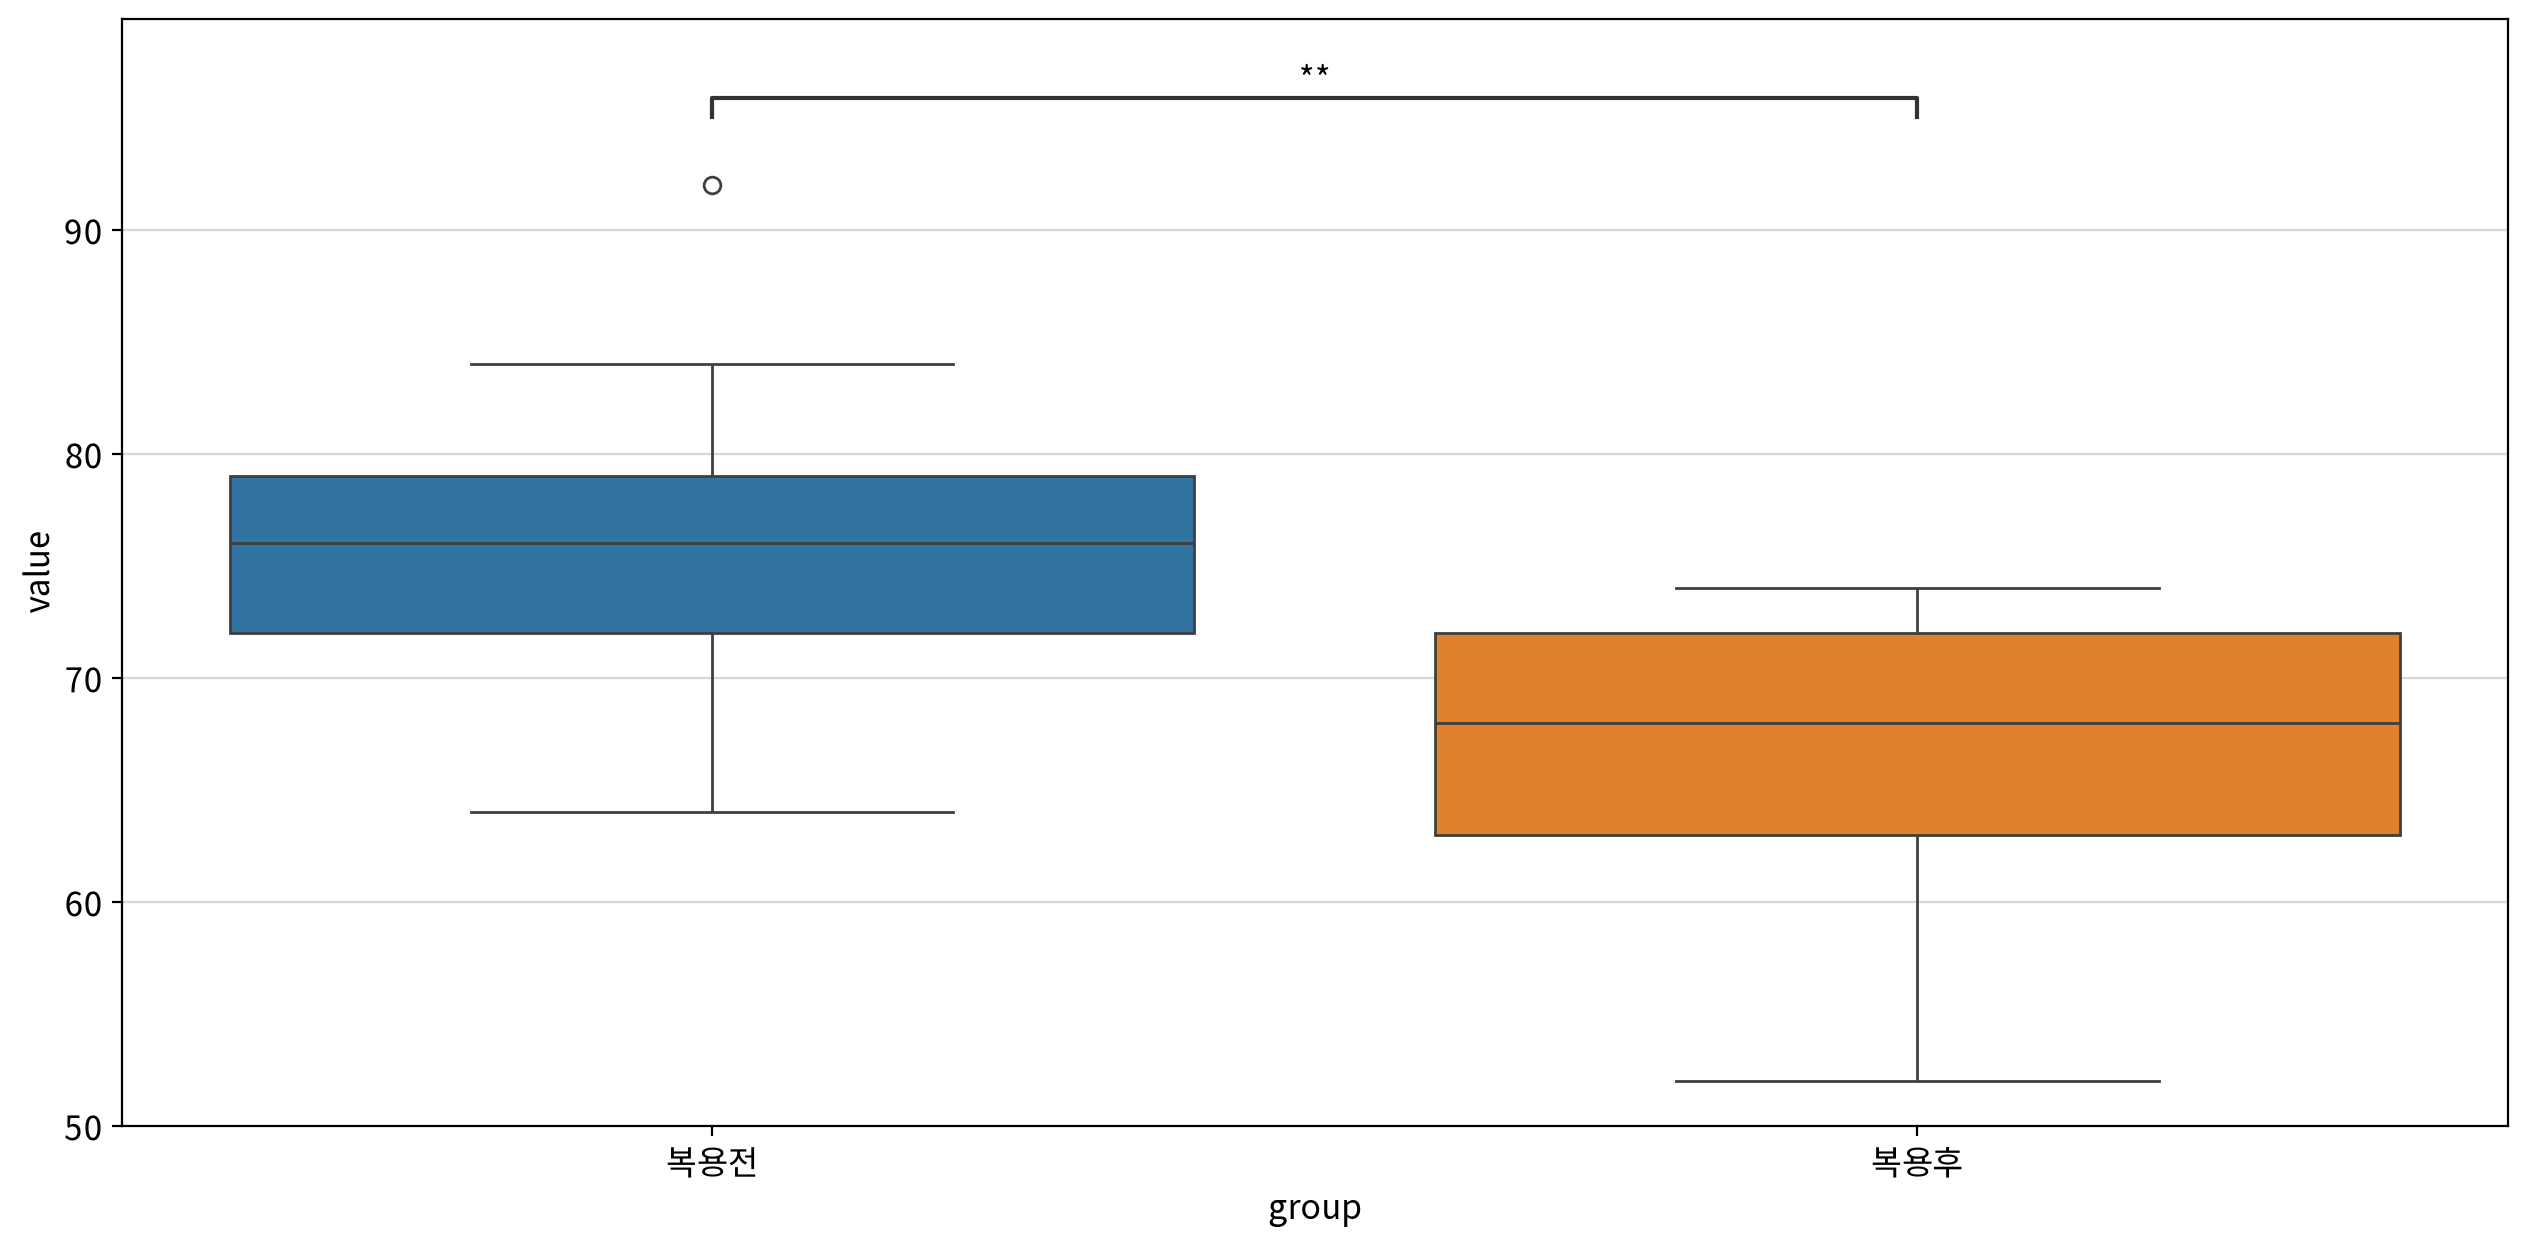

statistic  p-value  significant     result
test          alternative                                            
Paired t-test two-sided       -3.105    0.008         True  복용후 ≠ 복용전
              less            -3.105    0.004         True  복용후 < 복용전
              greater         -3.105    0.996        False  복용후 ≤ 복용전

In [23]:
# 데이터 불러오기
df = load_data('blood_pressure')
my_stats.test_paired(df, before='복용전', after='복용후')

#### 복용을 하면 영향을 준다

## 문제 2.
#### runner_diet 데이터셋은 고등학교 육상선수 10명에게 감량훈련(2~4kg 정도)을 시킨 후 100m 달리기를 실시한 결과를 조사한 데이터이다. 이를 통해 고등학교 육상선수에게 체중감량을 시키면 달리기에 어떤 변화가 일어나는지 조사하고자 한다. 감량 전 후 달리기 속도에 차이가 있는지 분석하라.

📚 고등학교 육상선수 10명에게 감량훈련(2~4kg 정도)을 시킨 후 100m 달리기를 실시한 결과를 조사한 데이터 (출처: 방송통신대학교 통계학개론)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 vs. 감량후: t-test paired samples, P_val:4.155e-02 t=2.375e+00


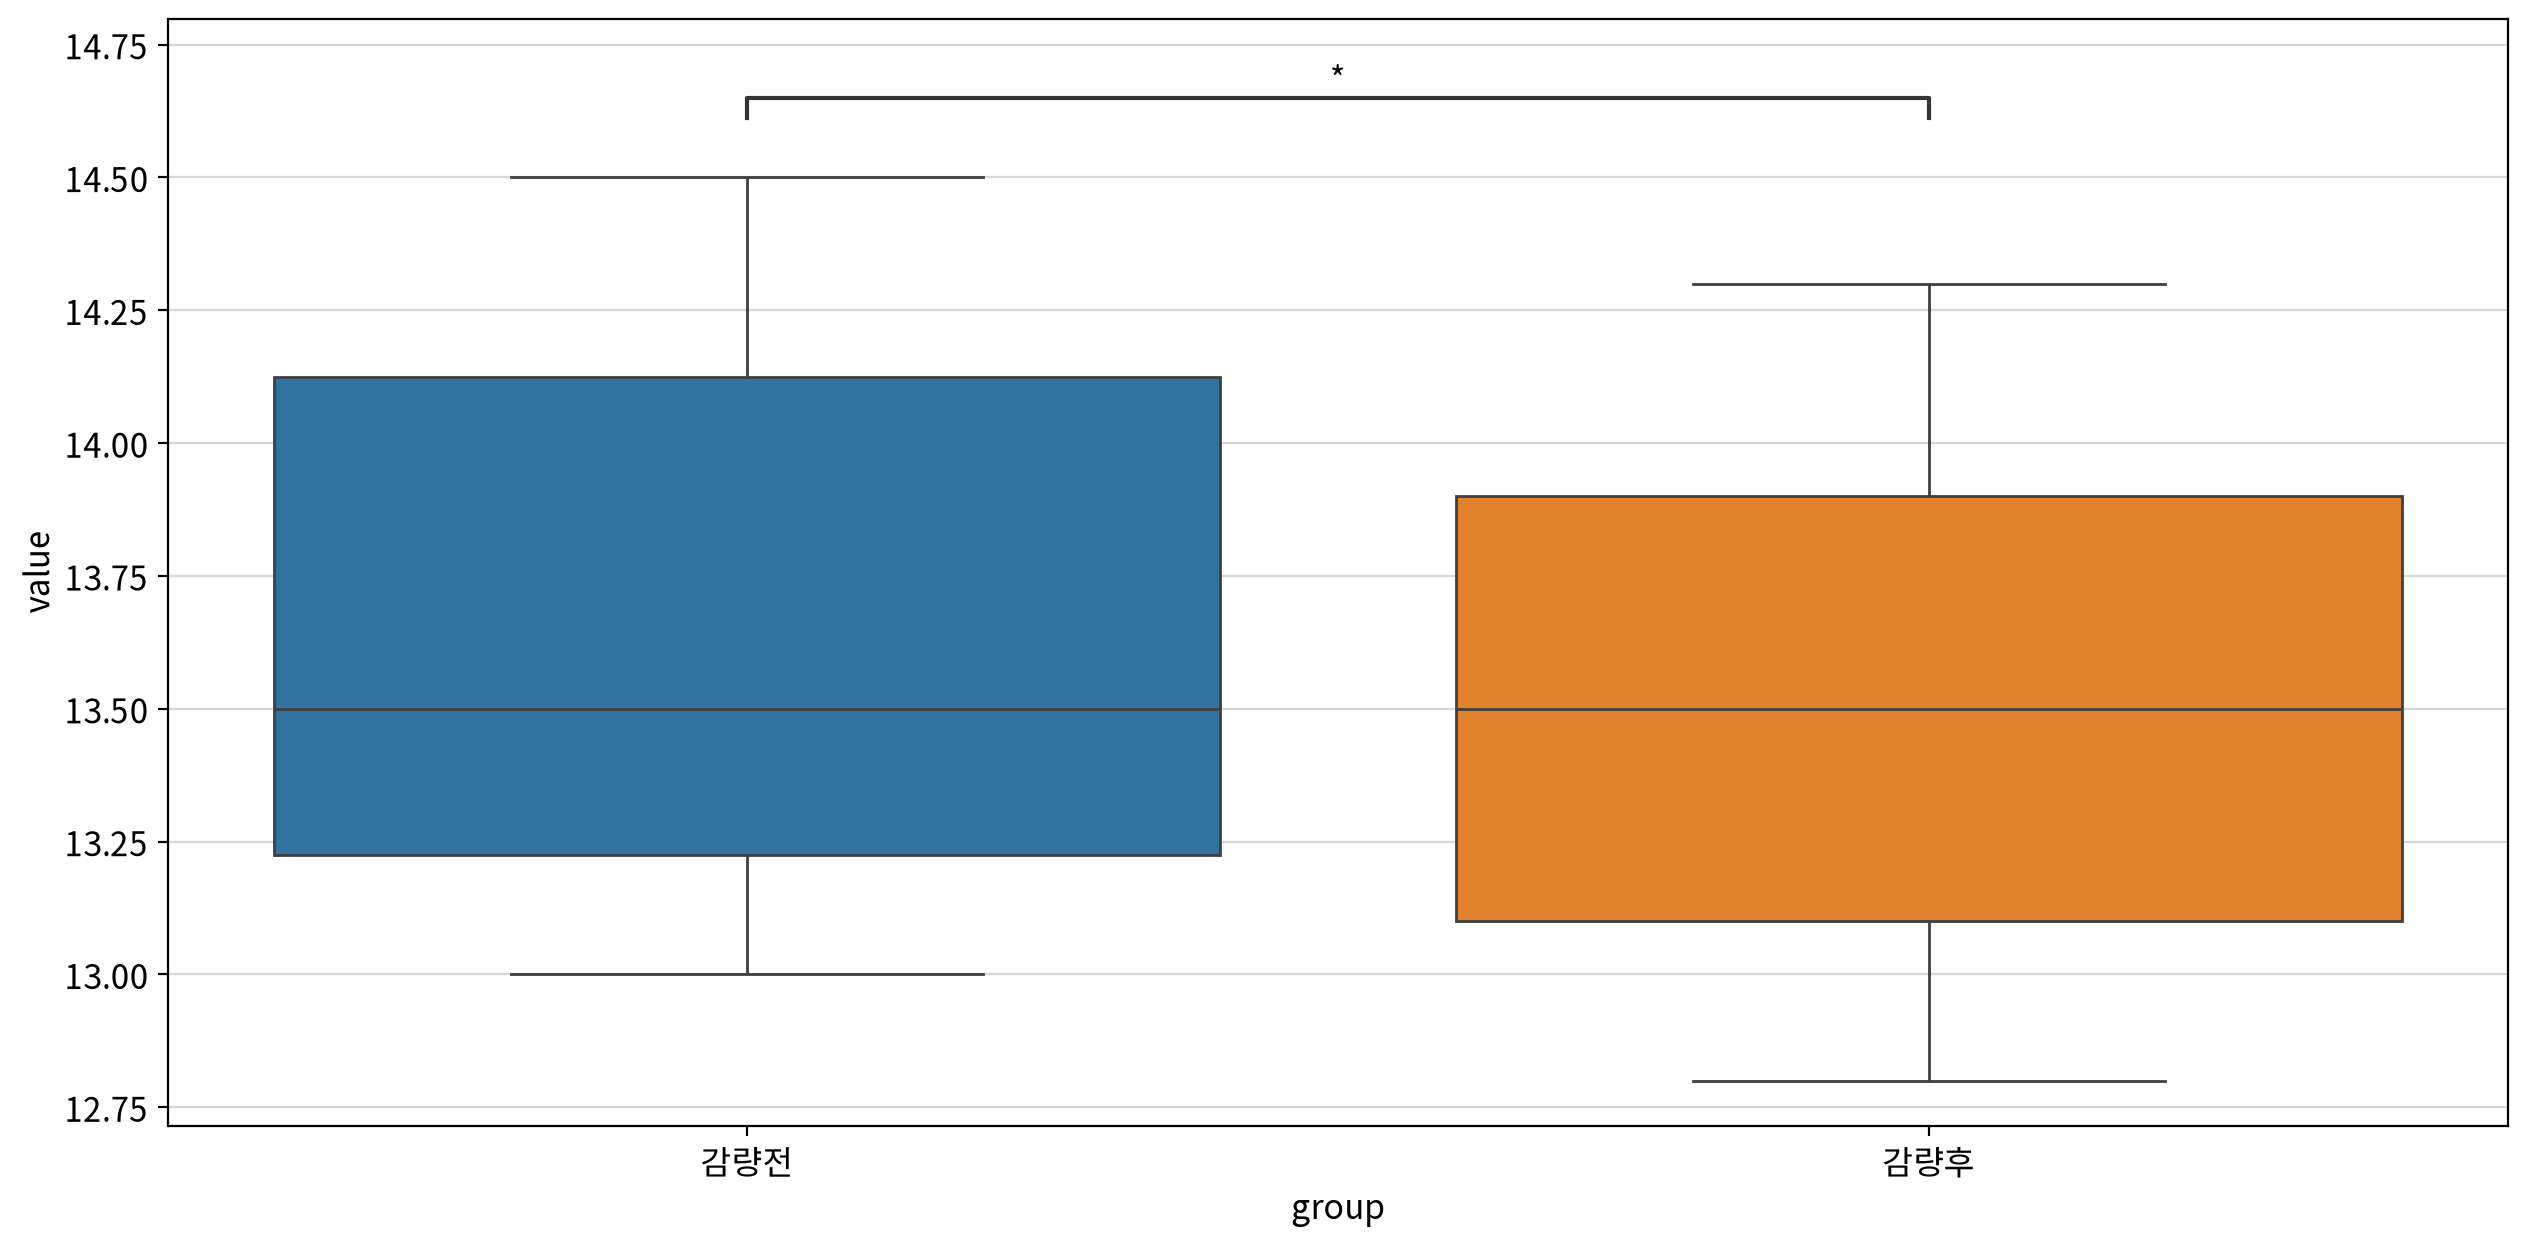

statistic  p-value  significant     result
test          alternative                                            
Paired t-test two-sided       -2.375    0.042         True  감량후 ≠ 감량전
              less            -2.375    0.021         True  감량후 < 감량전
              greater         -2.375    0.979        False  감량후 ≤ 감량전

In [26]:
df1 = load_data('runner_diet')
my_stats.test_paired(df1, before='감량전', after='감량후')

## 속도 차이에 변화가 없음

## 문제 3.
#### wrestler_diet 데이터셋은 고등학교 레슬링 선수에게 체중감량을 시키면 체력에 어떤 변화가 일어나는지 조사하기 위하여, 어느 고등학교의 레슬링 선수 12명을 표본추출하여 감량시킨 후 얻은 데이터이다.
#### 감량 전과 감량 후 간에 차이가 있는가의 대응비교를 악력, 윗몸일으키기, 턱걸이에 대하여 실시하고 분석하라

In [27]:
df2 = load_data('wrestler_diet')
df2.info()
df2

📚 고등학교 레슬링 선수에게 체중감량을 시키면 체력에 어떤 변화가 일어나는지 조사하기 위하여, 어느 고등학교의 레슬링 선수 12명을 표본추출하여 감량시킨 후 얻은 데이터 (출처: 방송통신대학교 통계학개론)
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   이름          12 non-null     str  
 1   감량전 악력      12 non-null     int64
 2   감량후 악력      12 non-null     int64
 3   감량전 윗몸일으키기  12 non-null     int64
 4   감량후 윗몸일으키기  12 non-null     int64
 5   감량전 턱걸이     12 non-null     int64
 6   감량후 턱걸이     12 non-null     int64
dtypes: int64(6), str(1)
memory usage: 840.0 bytes


,이름,감량전 악력,감량후 악력,감량전 윗몸일으키기,감량후 윗몸일으키기,감량전 턱걸이,감량후 턱걸이
0,B.S,43,41,35,41,25,29
1,P.J,42,41,40,44,25,29
2,G.G,52,50,36,41,22,23
3,A.L,53,52,38,42,10,15
4,I.H,44,40,36,42,15,19
5,B.Y,46,47,39,44,17,19
6,I.K,48,47,35,42,24,26
7,K.B,58,55,34,36,17,18
8,K.J,50,50,33,35,17,20
9,S.S,48,50,39,45,21,25


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 악력 vs. 감량후 악력: Wilcoxon test (paired samples), P_val:3.516e-02 Stat=9.000e+00


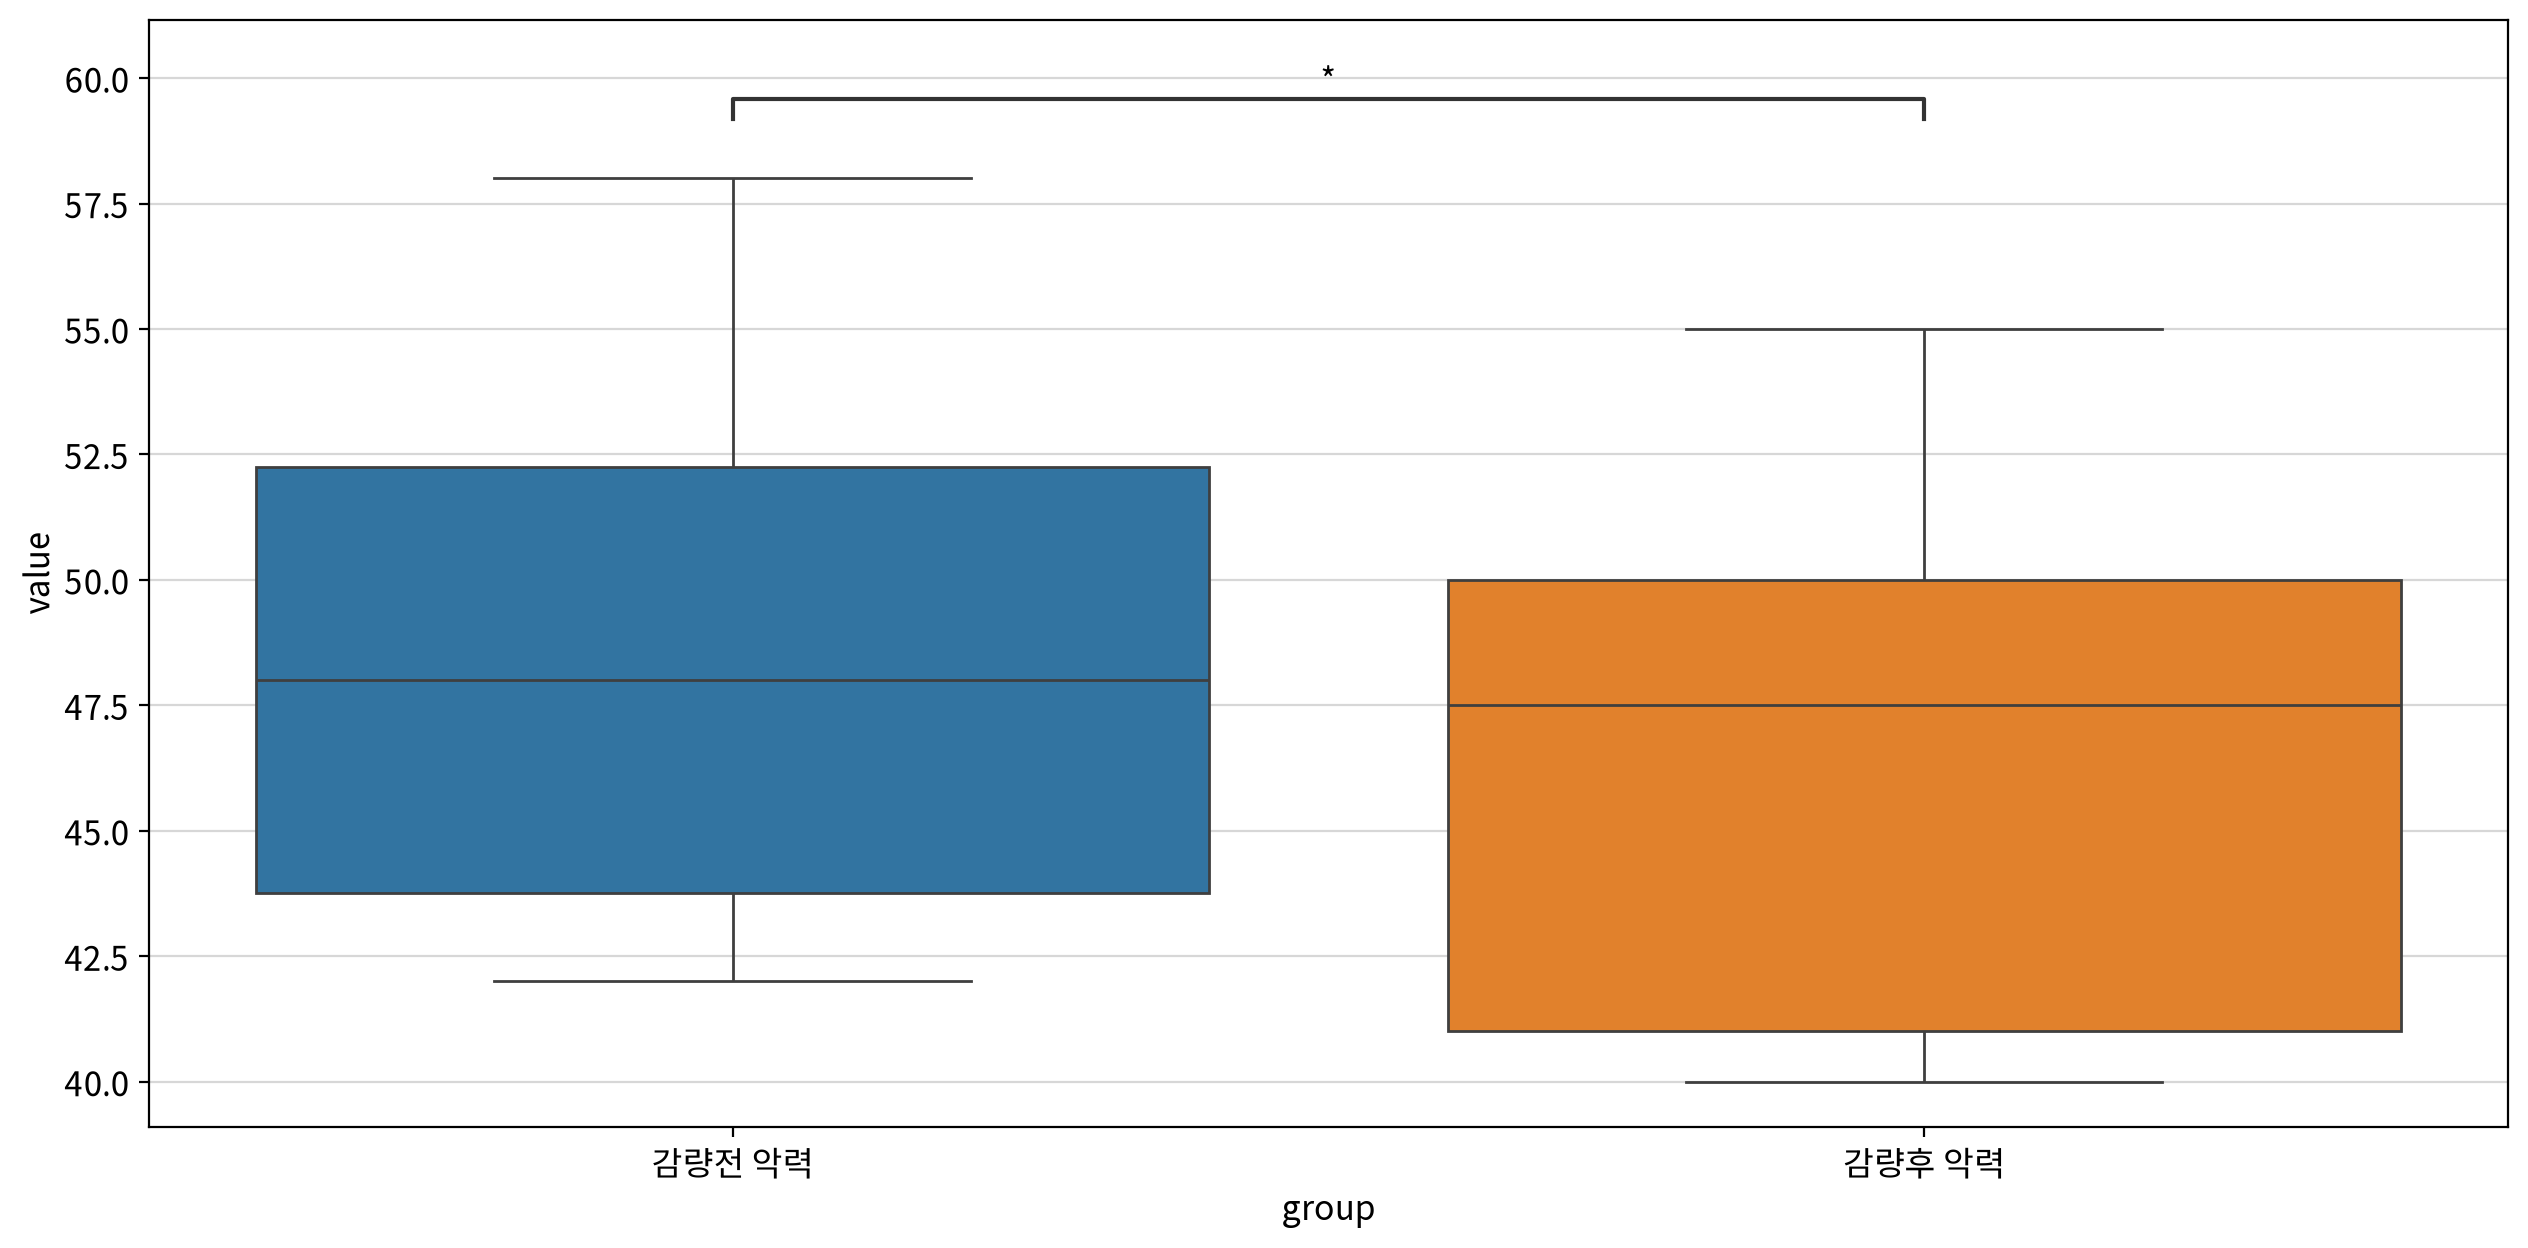

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided        9.000    0.035         True   
                          less             9.000    0.018         True   
                          greater          9.000    0.991        False   

                                                result  
test                      alternative                   
Wilcoxon signed-rank test two-sided    감량후 악력 ≠ 감량전 악력  
                          less         감량후 악력 < 감량전 악력  
                          greater      감량후 악력 ≤ 감량전 악력

In [31]:
my_stats.test_paired(df2, before='감량전 악력', after='감량후 악력')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 윗몸일으키기 vs. 감량후 윗몸일으키기: t-test paired samples, P_val:1.798e-05 t=-7.180e+00


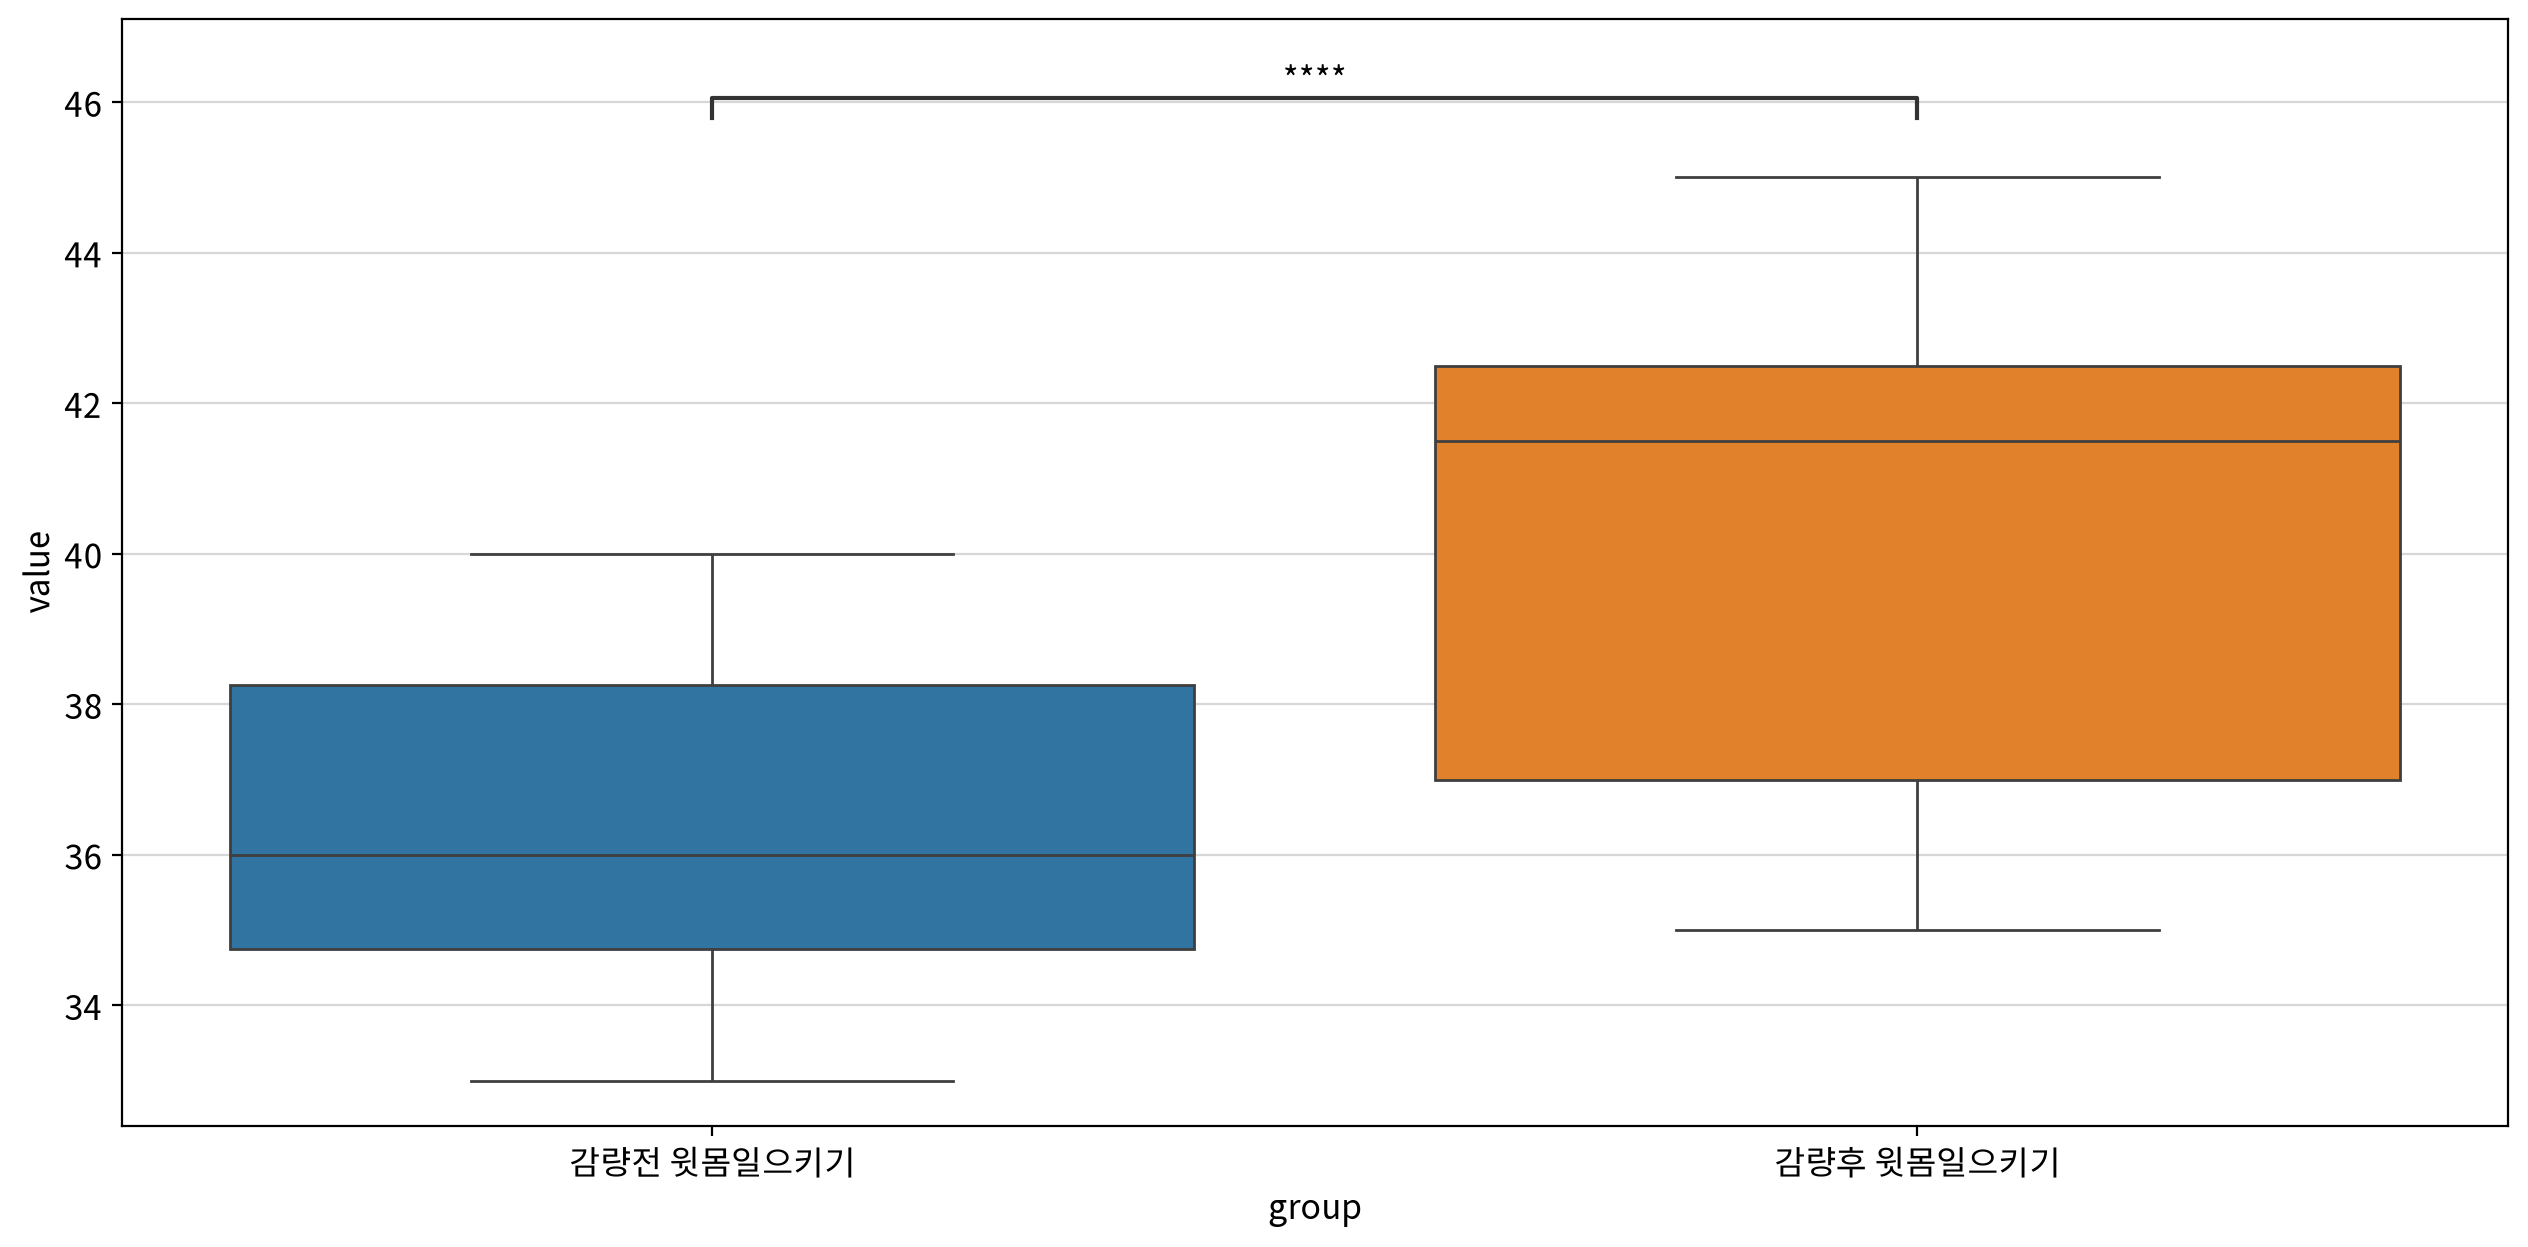

statistic  p-value  significant  \
test          alternative                                    
Paired t-test two-sided        7.180    0.000         True   
              less             7.180    1.000        False   
              greater          7.180    0.000         True   

                                            result  
test          alternative                           
Paired t-test two-sided    감량후 윗몸일으키기 ≠ 감량전 윗몸일으키기  
              less         감량후 윗몸일으키기 ≥ 감량전 윗몸일으키기  
              greater      감량후 윗몸일으키기 > 감량전 윗몸일으키기

In [32]:
my_stats.test_paired(df2, before= '감량전 윗몸일으키기', after='감량후 윗몸일으키기')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 턱걸이 vs. 감량후 턱걸이: t-test paired samples, P_val:2.794e-05 t=-6.842e+00


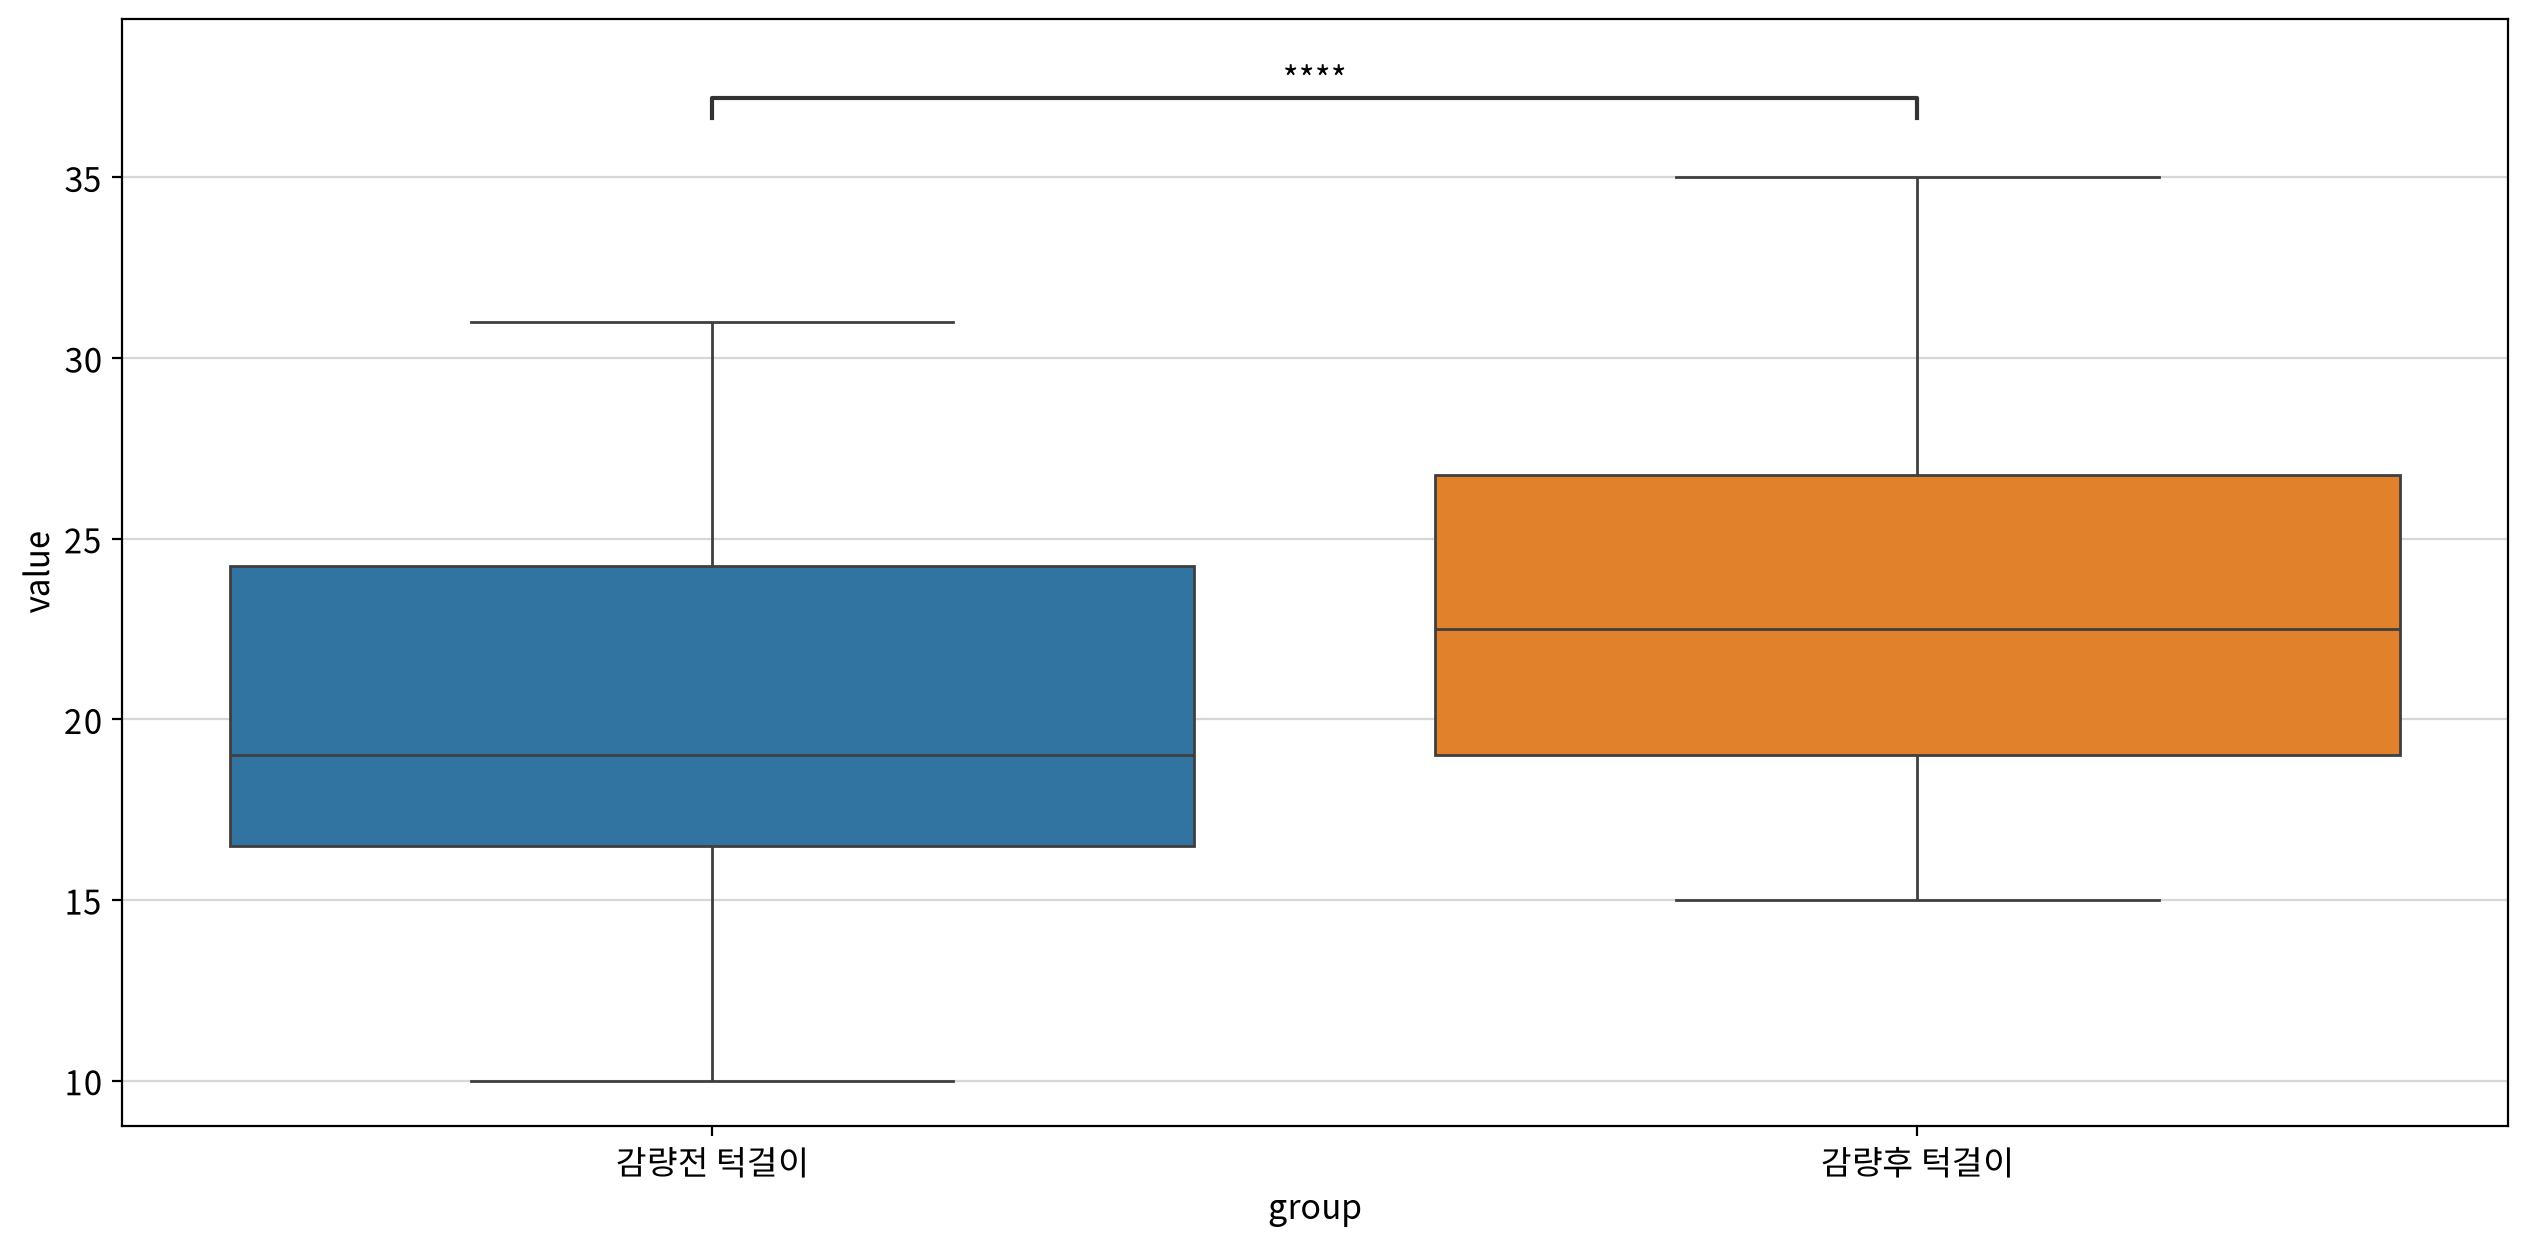

statistic  p-value  significant             result
test          alternative                                                    
Paired t-test two-sided        6.842    0.000         True  감량후 턱걸이 ≠ 감량전 턱걸이
              less             6.842    1.000        False  감량후 턱걸이 ≥ 감량전 턱걸이
              greater          6.842    0.000         True  감량후 턱걸이 > 감량전 턱걸이

In [33]:
my_stats.test_paired(df2, before='감량전 턱걸이', after='감량후 턱걸이')

## 문제 4.
#### 서울시에서 정의하는 상권의 종류는 발달상권, 골목상권, 관광특구, 전통시장이 있다.
#### commercial 데이터는 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료이다.
#### 주어진 데이터를 활용하여 서울시 골목상권의 2023년 상반기(1,2분기)와 하반기(3,4분기) 매출액이 어떤 차이를 보이는지 분석하라.
#### 주어진 데이터는 서울시에서 제공하는 집계가 완료된 데이터이므로 모든 결측치는 없는 상태이며 이상치도 실제 매출액 데이터이므로 별도의 정제 과정 없이 진행하는 것으로 한다.

In [43]:
# 데이터 불러오기
from pandas import pivot_table
df3 = load_data('commercial')
df3.info()
df3

📚 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료 (출처: 서울 열린데이터 광장)
<class 'pandas.DataFrame'>
RangeIndex: 6222 entries, 0 to 6221
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   quarter          6222 non-null   int64
 1   code             6222 non-null   int64
 2   type             6222 non-null   str  
 3   name             6222 non-null   str  
 4   sales_amount     6222 non-null   int64
 5   number_of_sales  6222 non-null   int64
dtypes: int64(4), str(2)
memory usage: 489.8 KB


,quarter,code,type,name,sales_amount,number_of_sales
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166
...,...,...,...,...,...,...
6217,4,3130323,전통시장,둔촌역전통시장,13523478306,535132
6218,4,3130324,전통시장,길동복조리시장,6236556030,330148
6219,4,3130325,전통시장,명일전통시장,3973269286,186049
6220,4,3130326,전통시장,고덕 골목형상점가,15013907999,755565


In [ ]:
# type을 타입별로 나누고 quarter를 상반기, 하반기로 나눠야한다.
df3['구분'] = df3['quarter'].map({1: '상반기', 2:'상반기', 3:'하반기',4:'하반기'})
df4 = df3[df3['type'] == '관광특구']
df5 = df3[df3['type'] == '발달상권']
df6 = df3[df3['type'] == '골목상권']
df7 = df3[df3['type'] == '전통시장']

In [65]:
df_관광특구 = pivot_table(df4, index='code', columns='구분', values='sales_amount')
df_발달상권 = pivot_table(df5, index='code', columns='구분', values='sales_amount')
df_골목상권 = pivot_table(df6, index='code', columns='구분', values='sales_amount')
df_전통시장 = pivot_table(df7, index='code', columns='구분', values='sales_amount')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상반기 vs. 하반기: Wilcoxon test (paired samples), P_val:3.125e-02 Stat=0.000e+00


c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_stats.py:43: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c])


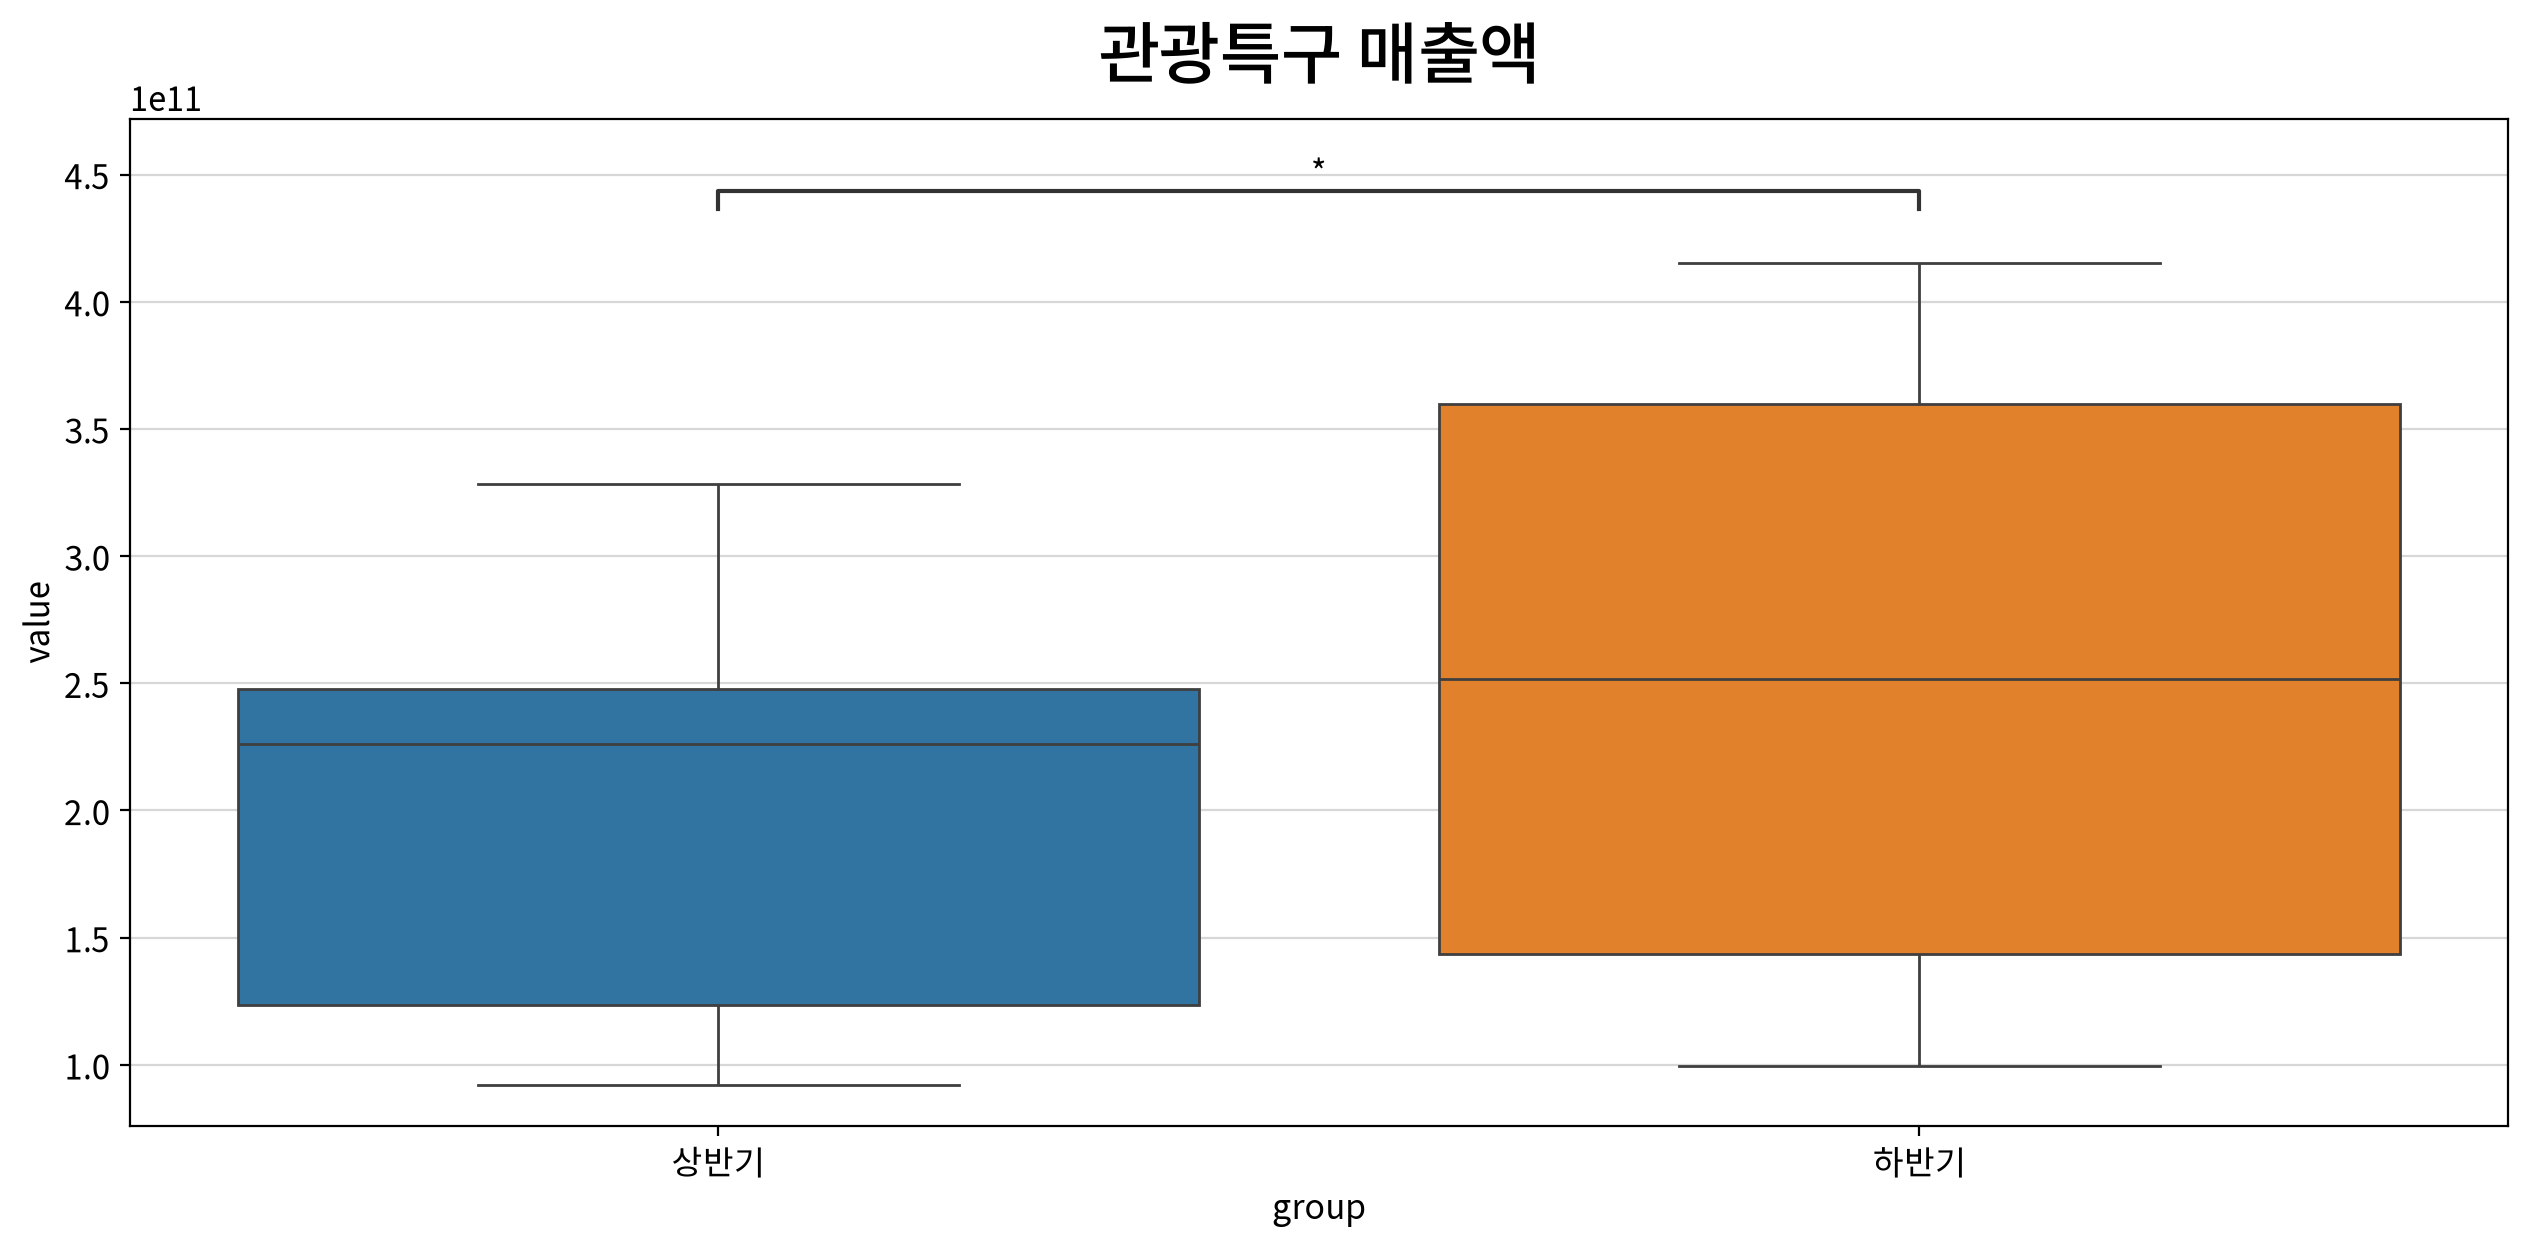

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided        0.000    0.031         True   
                          less            21.000    1.000        False   
                          greater         21.000    0.016         True   

                                          result  
test                      alternative             
Wilcoxon signed-rank test two-sided    하반기 ≠ 상반기  
                          less         하반기 ≥ 상반기  
                          greater      하반기 > 상반기

In [66]:
my_stats.test_paired(df_관광특구, before='상반기', after='하반기', title='관광특구 매출액')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상반기 vs. 하반기: Wilcoxon test (paired samples), P_val:3.573e-35 Stat=1.484e+03


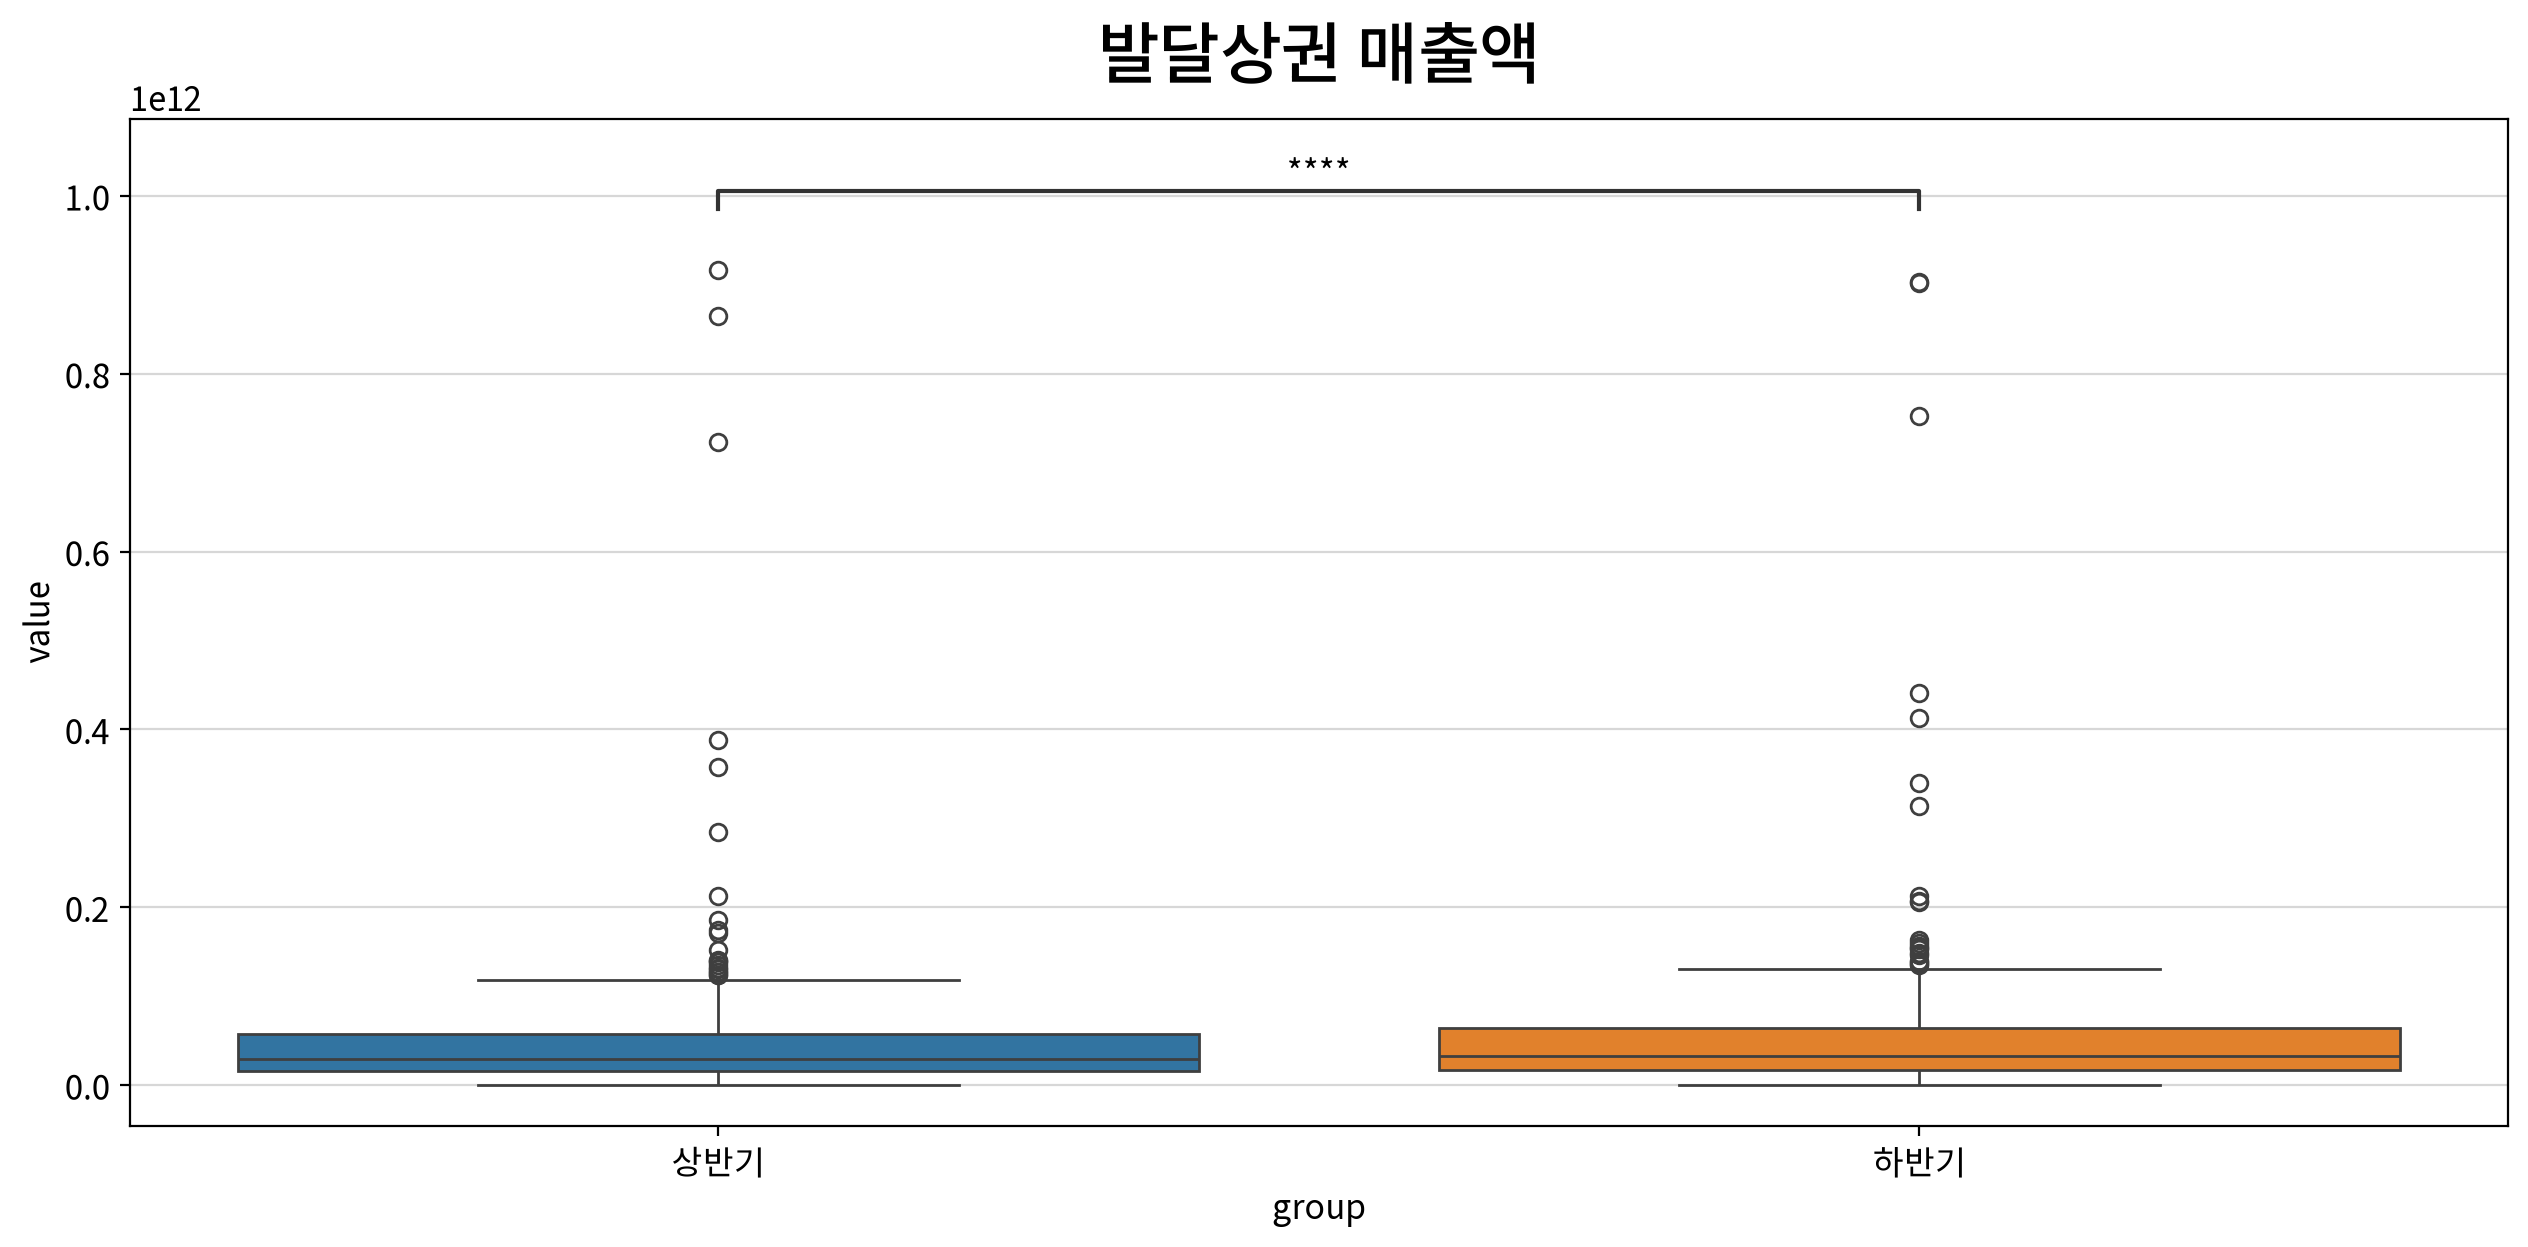

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided     1484.000    0.000         True   
                          less         29641.000    1.000        False   
                          greater      29641.000    0.000         True   

                                          result  
test                      alternative             
Wilcoxon signed-rank test two-sided    하반기 ≠ 상반기  
                          less         하반기 ≥ 상반기  
                          greater      하반기 > 상반기

In [67]:
my_stats.test_paired(df_발달상권, before='상반기', after='하반기', title='발달상권 매출액')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상반기 vs. 하반기: Wilcoxon test (paired samples), P_val:1.590e-94 Stat=6.624e+04


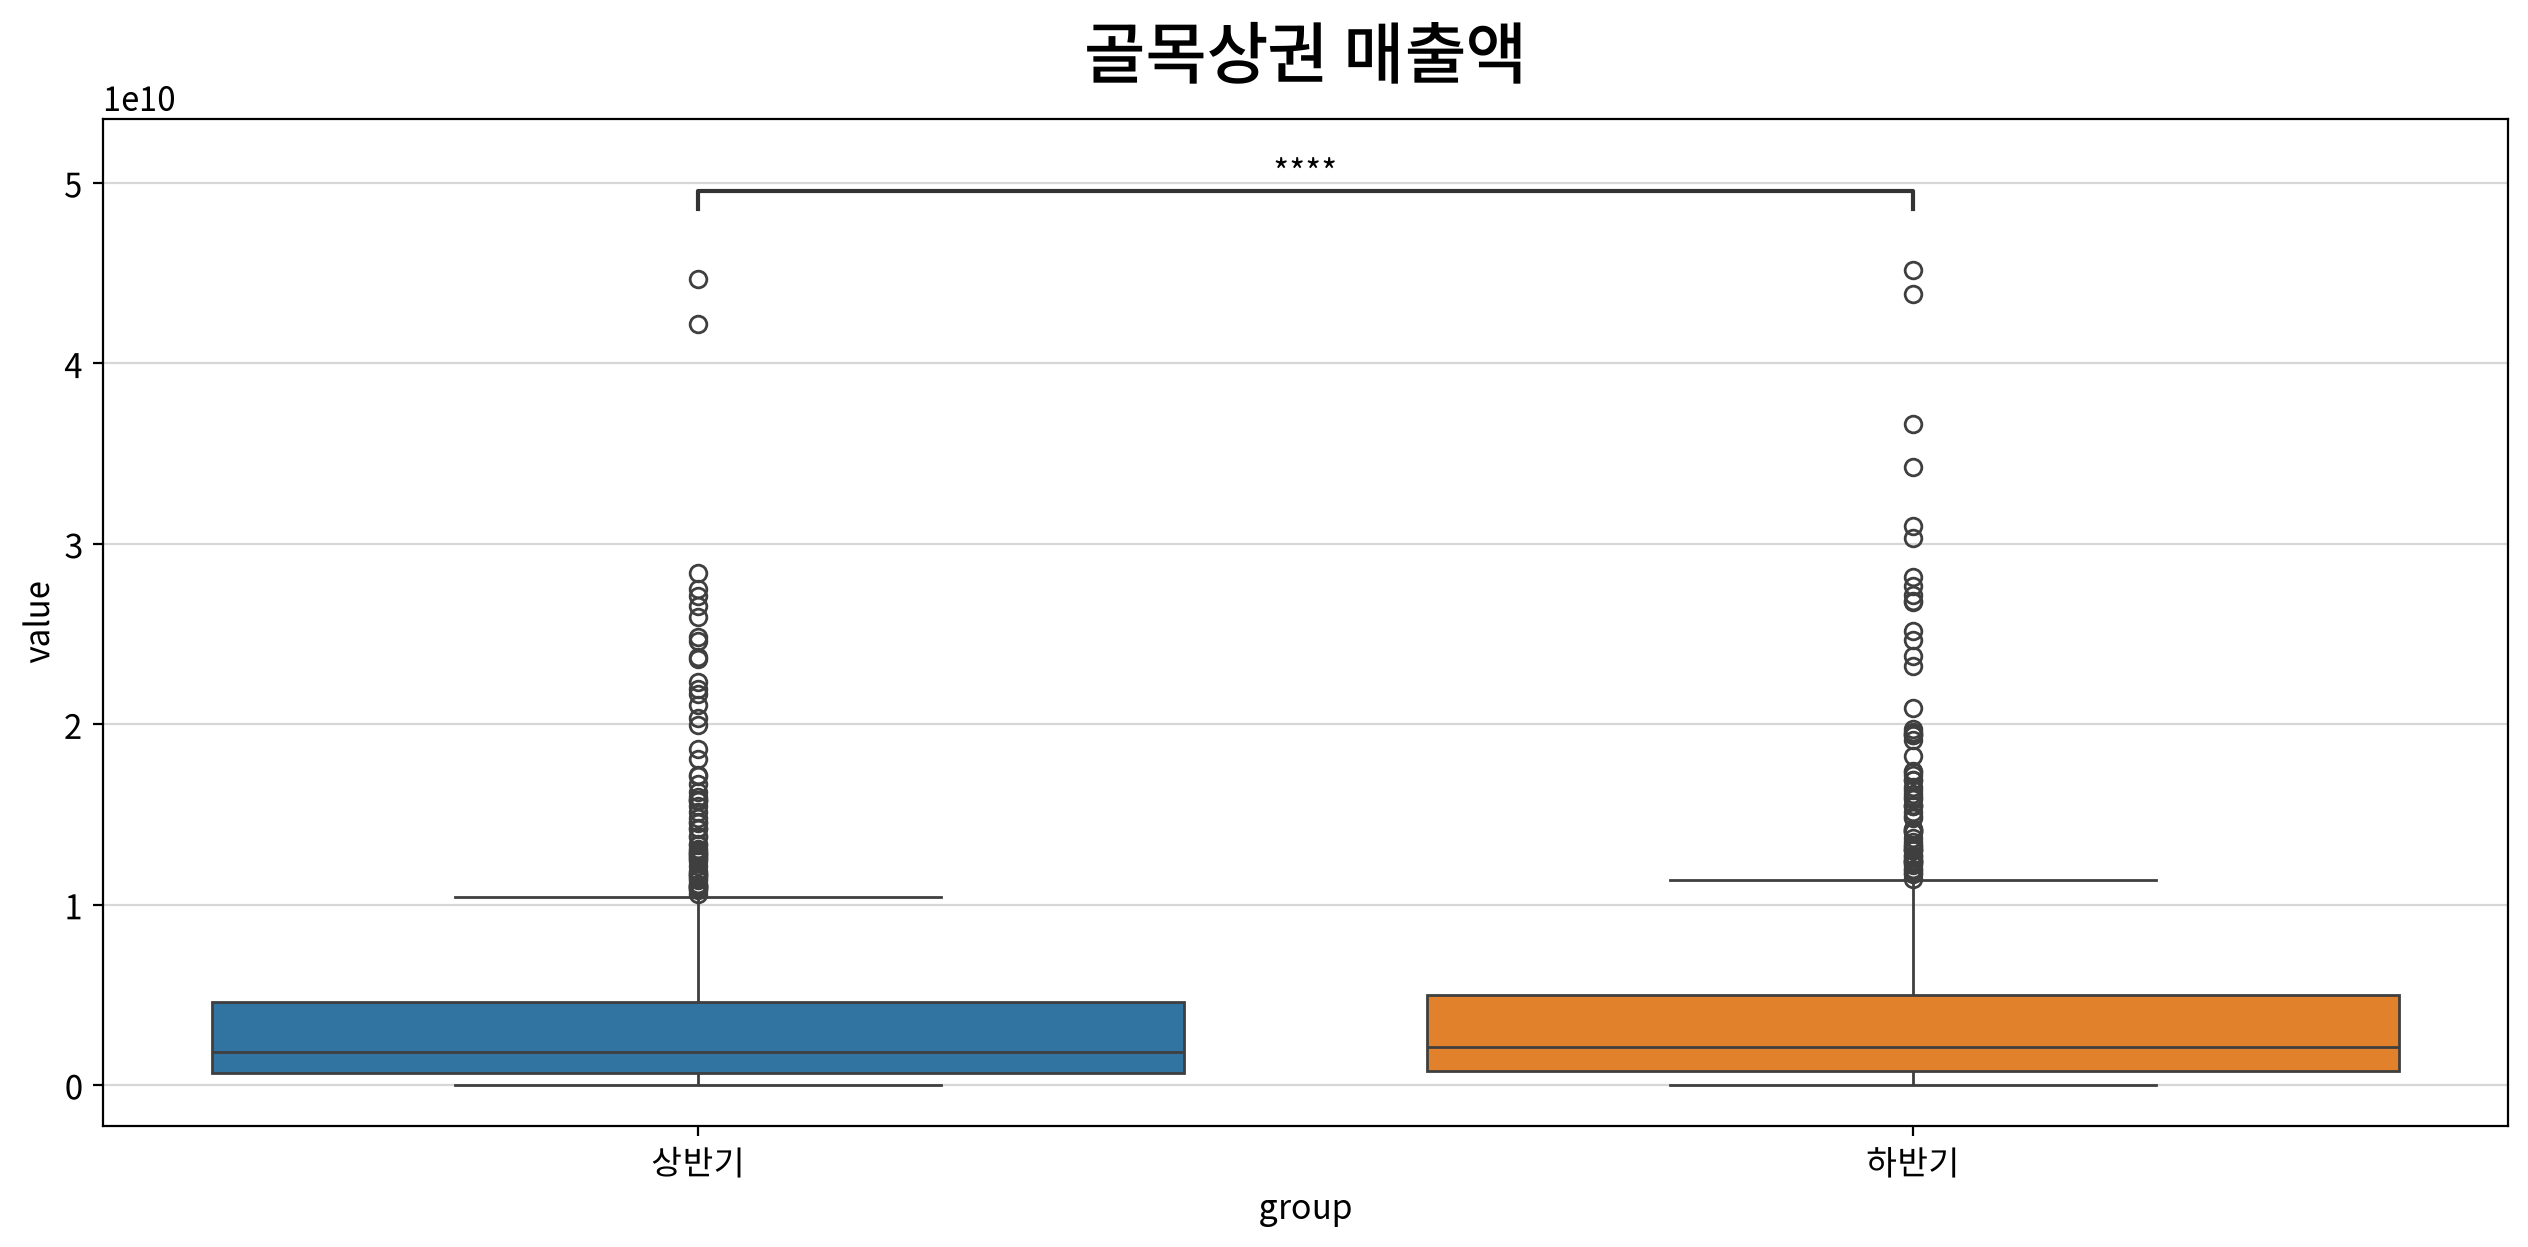

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided    66243.000    0.000         True   
                          less        454467.000    1.000        False   
                          greater     454467.000    0.000         True   

                                          result  
test                      alternative             
Wilcoxon signed-rank test two-sided    하반기 ≠ 상반기  
                          less         하반기 ≥ 상반기  
                          greater      하반기 > 상반기

In [68]:
my_stats.test_paired(df_골목상권, before='상반기', after='하반기', title='골목상권 매출액')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상반기 vs. 하반기: Wilcoxon test (paired samples), P_val:3.670e-28 Stat=4.333e+03


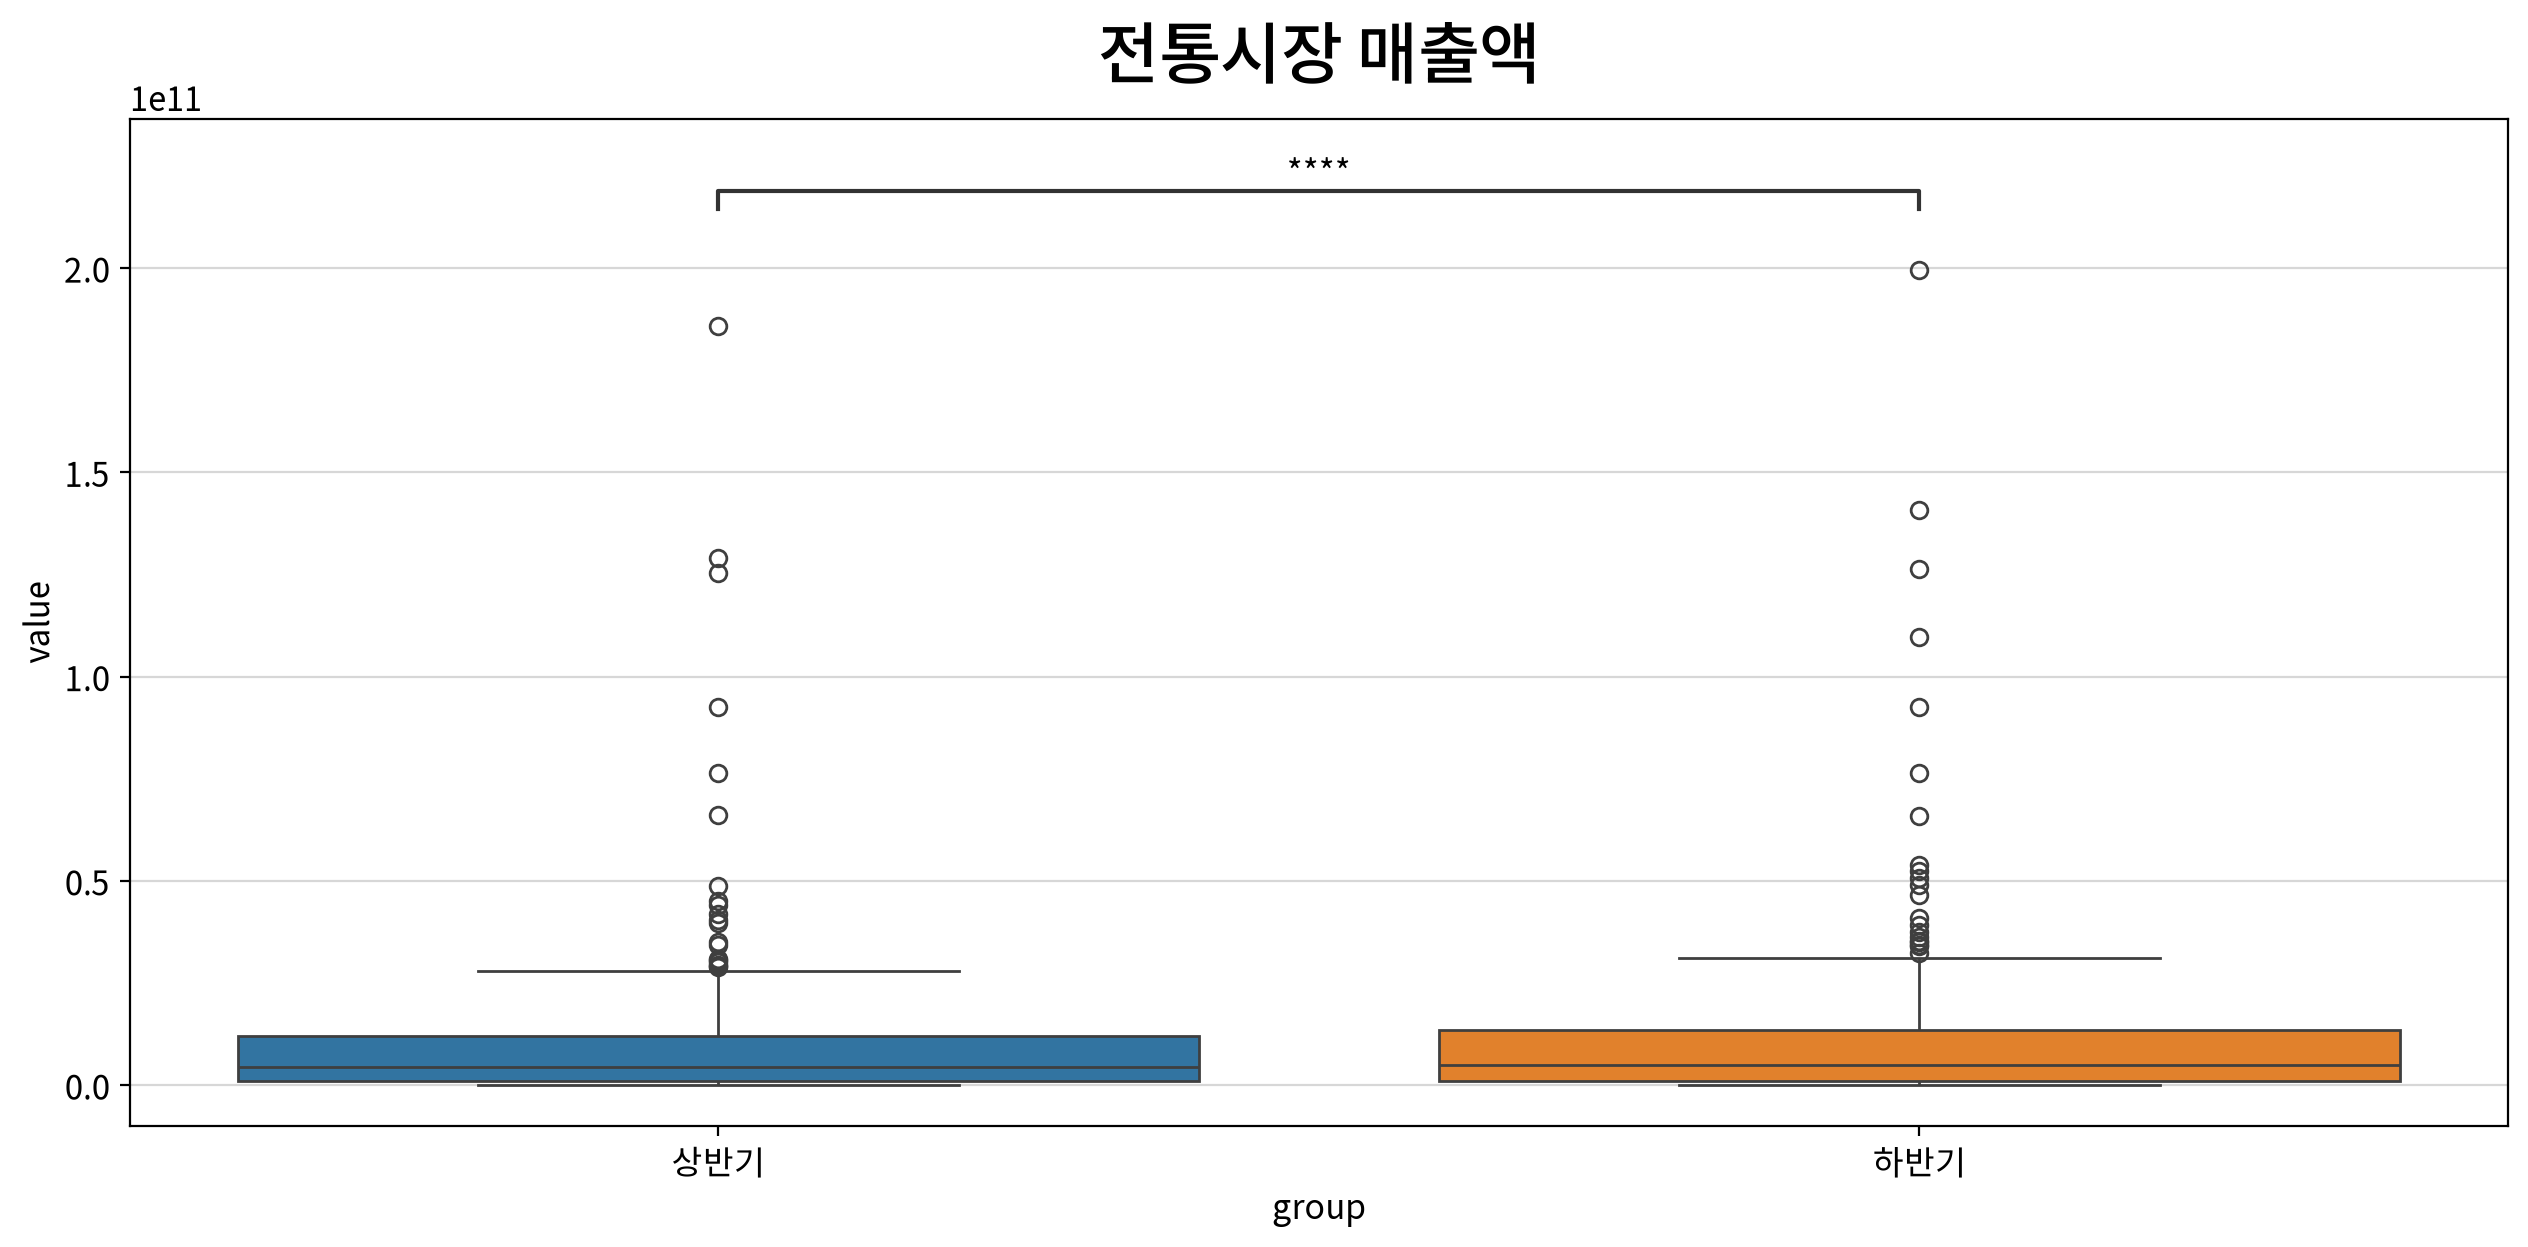

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided     4333.000    0.000         True   
                          less         33068.000    1.000        False   
                          greater      33068.000    0.000         True   

                                          result  
test                      alternative             
Wilcoxon signed-rank test two-sided    하반기 ≠ 상반기  
                          less         하반기 ≥ 상반기  
                          greater      하반기 > 상반기

In [69]:
my_stats.test_paired(df_전통시장, before='상반기', after='하반기', title='전통시장 매출액')